In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os

# ------------------ 1. Загрузка данных из обработанного CSV ------------------
DATA_PATH = 'data/processed/siddha_processed.csv'
df = pd.read_csv(DATA_PATH)  # колонки: user_id, activity, timestamp, gyro_x, gyro_y, gyro_z, acc_x, acc_y, acc_z

# Убедимся, что нет пропусков и нулевых временных меток (на всякий случай)
df = df.dropna()
#df = df[df['timestamp'] != 0]

# Сортируем по пользователю и времени (уже должно быть, но гарантируем)
df = df.sort_values(['user_id', 'activity', 'timestamp']).reset_index(drop=True)

# ------------------ 2. Создание окон ------------------
WINDOW_SIZE = 200
STEP = 100  # перекрытие 50%

# Признаки: все, кроме user_id, activity, timestamp
feature_cols = ['gyro_x', 'gyro_y', 'gyro_z', 'acc_x', 'acc_y', 'acc_z']

X_windows = []    # окна (WINDOW_SIZE, 6)
y_windows = []    # метки активности (уже числа 0..4)
user_windows = [] # ID пользователя для каждого окна

# Группируем по пользователю (данные внутри группы уже отсортированы по времени)
for user_id, group in df.groupby('user_id'):
    # Извлекаем массивы признаков и меток
    data = group[feature_cols].values        # shape (n, 6)
    activities = group['activity'].values    # shape (n,)
    
    n = len(data)
    if n < WINDOW_SIZE:
        continue  # недостаточно данных
    
    # Проходим по последовательности с шагом STEP
    for start in range(0, n - WINDOW_SIZE + 1, STEP):
        end = start + WINDOW_SIZE
        window_activities = activities[start:end]
        
        # Проверяем, что все активности в окне одинаковы
        if np.all(window_activities == window_activities[0]):
            X_windows.append(data[start:end])
            y_windows.append(window_activities[0])
            user_windows.append(user_id)

# Преобразуем в numpy
X_windows = np.array(X_windows)   # (num_windows, WINDOW_SIZE, 6)
y_windows = np.array(y_windows)   # (num_windows,)
user_windows = np.array(user_windows)

print(X_windows.shape)

print(f"Всего окон: {len(X_windows)}")
print(f"Уникальных пользователей с окнами: {len(np.unique(user_windows))}")

def split_and_scale_by_user(user_test, X_windows, y_windows, user_windows, WINDOW_SIZE, random_state=42):
    """
    Для заданного пользователя user_test:
      - он становится тестовым
      - из оставшихся выбирается один пользователь для валидации (только среди тех, у кого есть все активности)
      - остальные (все оставшиеся) – тренировка
    Возвращает:
      X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test
    """
    all_users = np.unique(user_windows)
    all_activities = np.unique(y_windows)
    
    # Определяем пользователей с полным набором активностей
    full_users = []
    for u in all_users:
        mask = (user_windows == u)
        user_acts = np.unique(y_windows[mask])
        if set(user_acts) == set(all_activities):
            full_users.append(u)
    
    # Исключаем тестового пользователя из списка для валидации
    candidates_for_val = [u for u in full_users if u != user_test]
    
    if len(candidates_for_val) == 0:
        raise ValueError(f"Нет пользователей с полным набором активностей для валидации (кроме тестового {user_test})")
    
    # Случайно выбираем одного валидационного из кандидатов
    rng = np.random.RandomState(random_state)
    val_user = rng.choice(candidates_for_val, 1)[0]
    
    # Все остальные пользователи (включая тех, у кого неполный набор) идут в тренировку, кроме тестового и валидационного
    train_users = [u for u in all_users if u != user_test and u != val_user]
    
    print(f"Test user: {user_test}, Val user: {val_user}, Train users: {len(train_users)}")
    
    # Фильтруем окна
    train_mask = np.isin(user_windows, train_users)
    val_mask = (user_windows == val_user)
    test_mask = (user_windows == user_test)
    
    X_train = X_windows[train_mask]
    y_train = y_windows[train_mask]
    X_val = X_windows[val_mask]
    y_val = y_windows[val_mask]
    X_test = X_windows[test_mask]
    y_test = y_windows[test_mask]
    
    print(f"Train windows: {len(X_train)}, Val windows: {len(X_val)}, Test windows: {len(X_test)}")
    
    # ------------------ Масштабирование (только по train) ------------------
    X_train_flat = X_train.reshape(-1, 3)
    scaler = StandardScaler()
    scaler.fit(X_train_flat)
    
    def scale_data(X):
        original_shape = X.shape
        X_flat = X.reshape(-1, 3)
        X_scaled = scaler.transform(X_flat)
        return X_scaled.reshape(original_shape)
    
    X_train_scaled = scale_data(X_train)
    X_val_scaled = scale_data(X_val)
    X_test_scaled = scale_data(X_test)
    
    return X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test

(8504, 200, 6)
Всего окон: 8504
Уникальных пользователей с окнами: 51


In [2]:
# Train function

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
import os
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def train_model(model, model_name, train_loader, val_loader, test_loader,
                num_epochs=50, lr=0.001, device='cuda', weights=None, save_dir='models'):
    """
    Обучение с динамическим обновлением вывода (Jupyter/Colab).
    Каждая эпоха перерисовывает: прогресс, лучший F1, графики потерь и F1.
    """
    os.makedirs(save_dir, exist_ok=True)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total trainable parameters: {total_params}")
    
    model = model.to(device)
    if weights is not None:
        weights = weights.to(device)
    
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)
    
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_f1': [], 'val_f1': []
    }
    
    best_val_f1 = -1.0
    best_epoch = 0
    best_model_state = None

    epoch_bar = tqdm(range(1, num_epochs + 1), desc='Training', unit='epoch')
    for epoch in epoch_bar:
        # ---------- Train ----------
        model.train()
        train_losses = []
        train_preds = []
        train_labels = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.float().to(device)
            y_batch = y_batch.long().to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            preds = torch.argmax(outputs, dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(y_batch.cpu().numpy())
        
        train_loss = np.mean(train_losses)
        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average='macro')
        
        # ---------- Validation ----------
        model.eval()
        val_losses = []
        val_preds = []
        val_labels = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.float().to(device)
                y_batch = y_batch.long().to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
                preds = torch.argmax(outputs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(y_batch.cpu().numpy())
        
        val_loss = np.mean(val_losses)
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average='macro')
        
        # Сохраняем историю
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        scheduler.step(val_loss)
        
        # Обновляем лучшую модель
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_model_state = model.state_dict().copy()
        
        # Сохраняем историю и проверяем лучший результат
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_model_state = model.state_dict().copy()
            # Выводим строку с лучшим значением (не ломает бар)
            tqdm.write(f'⭐ Best val F1 = {best_val_f1:.4f} at epoch {best_epoch}')
        
        # Обновляем единственный прогресс-бар
        epoch_bar.set_postfix({
            'TL': f'{train_loss:.3f}',
            'VL': f'{val_loss:.3f}',
            'VF': f'{val_f1:.3f}',
            'best VF': f'{best_val_f1:.3f}' if best_val_f1 > -1 else '-',
            'best Epoch': f'{best_epoch}'
        })
    
    # ---------- Загрузка лучшей модели и сохранение ----------
    model.load_state_dict(best_model_state)
    torch.save(model.state_dict(), os.path.join(save_dir, f"{model_name}.pt"))

    # 2. Графики
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='train')
    ax1.plot(history['val_loss'], label='val')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid(True)
        
    ax2.plot(history['train_f1'], label='train')
    ax2.plot(history['val_f1'], label='val')
    ax2.set_title('F1 (macro)')
    ax2.legend()
    ax2.grid(True)
        
    plt.tight_layout()
    plt.show()
    
    # ---------- Тест (финальный вывод после обучения) ----------
    #clear_output(wait=True)  # очищаем последний вывод с графиками
    print(f"Training complete. Best val F1 = {best_val_f1:.4f} at epoch {best_epoch}")
    print(f"Model saved to {save_dir}/{model_name}.pt")
    
    model.eval()
    test_preds = []
    test_labels = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.float().to(device)
            y_batch = y_batch.long().to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)
            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(y_batch.cpu().numpy())
    
    print("\n========== Test Set Evaluation ==========")
    print(classification_report(test_labels, test_preds, digits=4))
    test_acc = accuracy_score(test_labels, test_preds)
    test_f1_macro = f1_score(test_labels, test_preds, average='macro')
    test_precision_macro = precision_score(test_labels, test_preds, average='macro')
    test_recall_macro = recall_score(test_labels, test_preds, average='macro')
    print(f"Overall Accuracy: {test_acc:.4f}")
    print(f"Macro Precision: {test_precision_macro:.4f}")
    print(f"Macro Recall:    {test_recall_macro:.4f}")
    print(f"Macro F1:        {test_f1_macro:.4f}")
    print("==========================================")
    
    return model, history, test_f1_macro

In [3]:
from ncps.torch import CfC

class LNNConvClassifier(nn.Module):
    def __init__(self, input_size, hidden_units, num_classes, dropout_rate=0.3):
        super(LNNConvClassifier, self).__init__()
        self.cfc = CfC(input_size=input_size, units=hidden_units)
        
        # Три 1D свертки с уменьшением временной размерности в 2 раза после каждой
        self.conv1 = nn.Sequential(
            nn.Conv1d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_units),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.MaxPool1d(kernel_size=2, stride=2)  # уменьшает длину вдвое
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_units),
            nn.ReLU(inplace=True),
            #nn.Dropout(dropout_rate),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_units),
            nn.ReLU(inplace=True),
            #nn.Dropout(dropout_rate),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        # Глобальный макс пулинг в конце
        self.global_max_pool = nn.AdaptiveMaxPool1d(1)
        self.dropout_cl = nn.Dropout(0.5)
        self.classifier = nn.Linear(hidden_units, num_classes)
        
    def forward(self, x):
        # x: (batch, seq_len, input_size)
        outputs, _ = self.cfc(x)          # (batch, seq_len, hidden_units)
        # Переставляем для 1D сверток: (batch, hidden_units, seq_len)
        out = outputs.permute(0, 2, 1)
        out = self.conv1(out)
        out = self.conv2(out)
        out = self.conv3(out)
        out = self.global_max_pool(out)   # (batch, hidden_units, 1)
        out = out.squeeze(-1)             # (batch, hidden_units)
        oot = self.dropout_cl(out)
        return self.classifier(out)



 Train 1/51,	 User 0
Test user: 0, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|███████| 300/300 [03:58<00:00,  1.26epoch/s, TL=0.279, VL=0.437, VF=0.879, best VF=0.952, best Epoch=73]


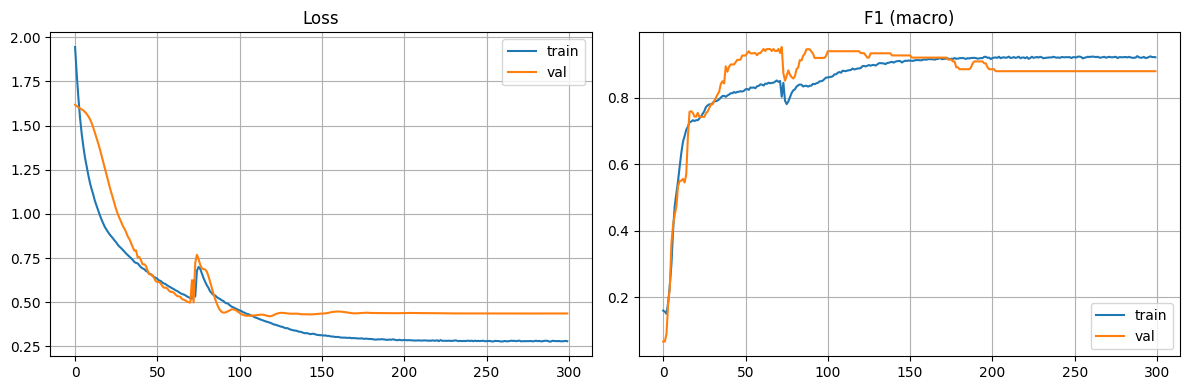

Training complete. Best val F1 = 0.9518 at epoch 73
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.8293    1.0000    0.9067        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    0.7941    0.8852        34
           3     1.0000    0.0588    0.1111        34
           4     0.5152    1.0000    0.6800        34

    accuracy                         0.7706       170
   macro avg     0.8689    0.7706    0.7166       170
weighted avg     0.8689    0.7706    0.7166       170

Overall Accuracy: 0.7706
Macro Precision: 0.8689
Macro Recall:    0.7706
Macro F1:        0.7166


 Train 2/51,	 User 1
Test user: 1, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:58<00:00,  1.26epoch/s, TL=0.146, VL=0.358, VF=0.711, best VF=0.959, best Epoch=174]


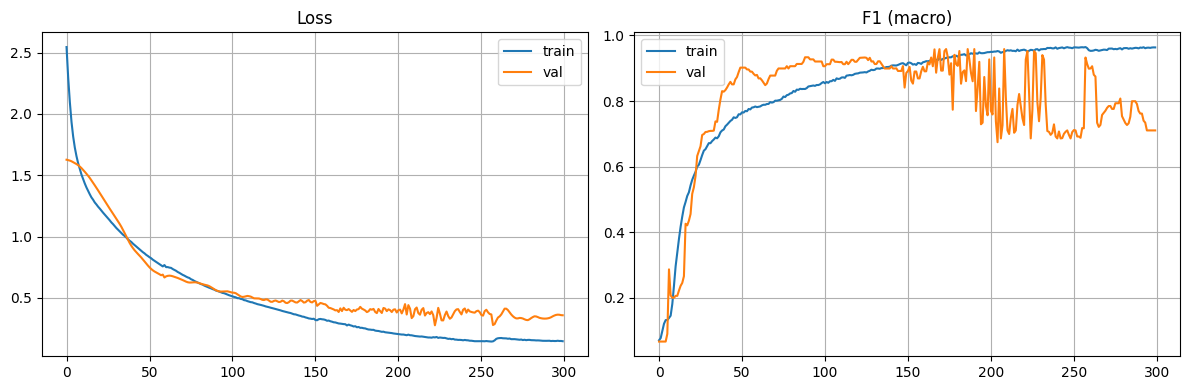

Training complete. Best val F1 = 0.9586 at epoch 174
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.7941    0.8852        34
           1     1.0000    1.0000    1.0000        34
           2     0.9444    1.0000    0.9714        34
           3     0.0000    0.0000    0.0000        34
           4     0.4658    1.0000    0.6355        34

    accuracy                         0.7588       170
   macro avg     0.6820    0.7588    0.6984       170
weighted avg     0.6820    0.7588    0.6984       170

Overall Accuracy: 0.7588
Macro Precision: 0.6820
Macro Recall:    0.7588
Macro F1:        0.6984


 Train 3/51,	 User 2
Test user: 2, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|███████| 300/300 [03:57<00:00,  1.26epoch/s, TL=0.159, VL=0.262, VF=0.959, best VF=0.965, best Epoch=98]


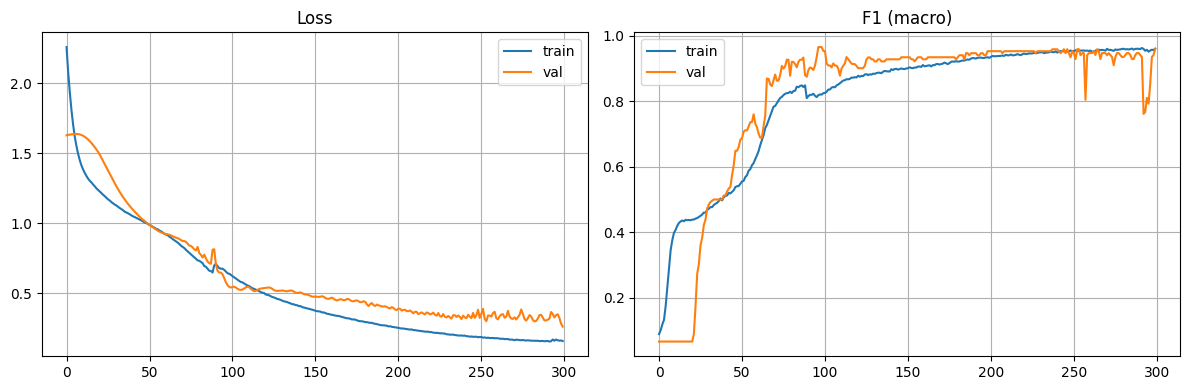

Training complete. Best val F1 = 0.9650 at epoch 98
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9189    1.0000    0.9577        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    0.9118    0.9538        34
           3     0.9714    1.0000    0.9855        34
           4     1.0000    0.9706    0.9851        34

    accuracy                         0.9765       170
   macro avg     0.9781    0.9765    0.9764       170
weighted avg     0.9781    0.9765    0.9764       170

Overall Accuracy: 0.9765
Macro Precision: 0.9781
Macro Recall:    0.9765
Macro F1:        0.9764


 Train 4/51,	 User 3
Test user: 3, Val user: 43, Train users: 49
Train windows: 8163, Val windows: 170, Test windows: 171
Class weights: tensor([0.9788, 0.9998, 1.0439, 0.9800, 1.0004])
Total trainable parameters: 13733


Training: 100%|███████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.136, VL=0.368, VF=0.852, best VF=0.970, best Epoch=86]


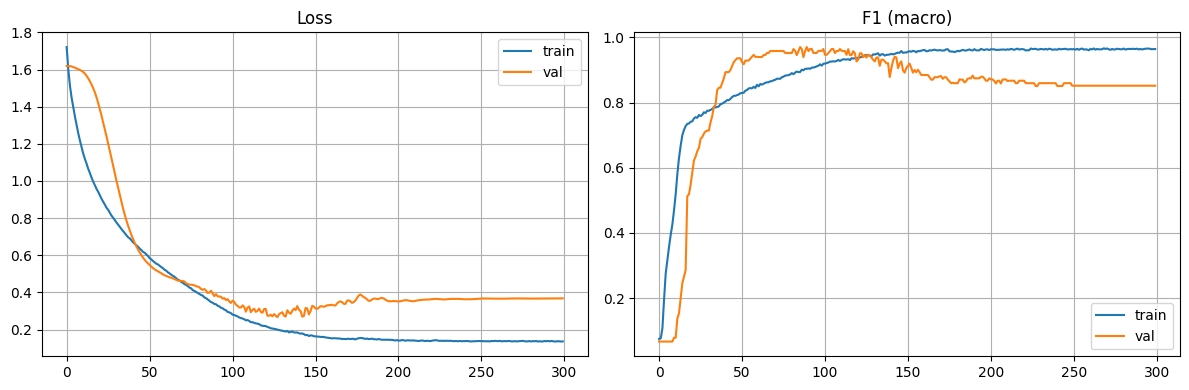

Training complete. Best val F1 = 0.9703 at epoch 86
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.7714    0.8710        35
           1     1.0000    1.0000    1.0000        34
           2     0.8049    0.9706    0.8800        34
           3     1.0000    0.0294    0.0571        34
           4     0.5000    1.0000    0.6667        34

    accuracy                         0.7544       171
   macro avg     0.8610    0.7543    0.6950       171
weighted avg     0.8618    0.7544    0.6960       171

Overall Accuracy: 0.7544
Macro Precision: 0.8610
Macro Recall:    0.7543
Macro F1:        0.6950


 Train 5/51,	 User 4
Test user: 4, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.188, VL=0.317, VF=0.918, best VF=0.927, best Epoch=169]


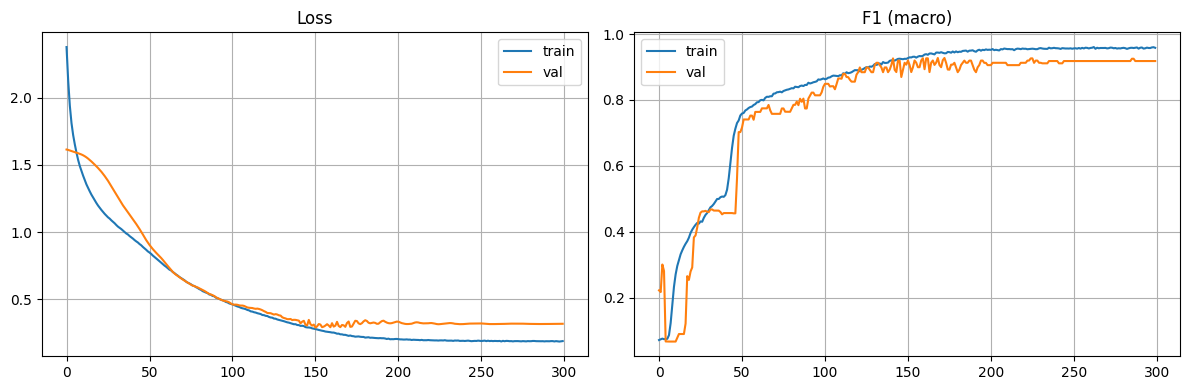

Training complete. Best val F1 = 0.9273 at epoch 169
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9706    0.9706    0.9706        34
           1     1.0000    1.0000    1.0000        34
           2     0.9706    0.9706    0.9706        34
           3     0.5517    0.9412    0.6957        34
           4     0.8000    0.2353    0.3636        34

    accuracy                         0.8235       170
   macro avg     0.8586    0.8235    0.8001       170
weighted avg     0.8586    0.8235    0.8001       170

Overall Accuracy: 0.8235
Macro Precision: 0.8586
Macro Recall:    0.8235
Macro F1:        0.8001


 Train 6/51,	 User 5
Test user: 5, Val user: 43, Train users: 49
Train windows: 8162, Val windows: 170, Test windows: 172
Class weights: tensor([0.9787, 1.0002, 1.0437, 0.9798, 1.0002])
Total trainable parameters: 13733


Training: 100%|███████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.159, VL=0.466, VF=0.685, best VF=0.916, best Epoch=68]


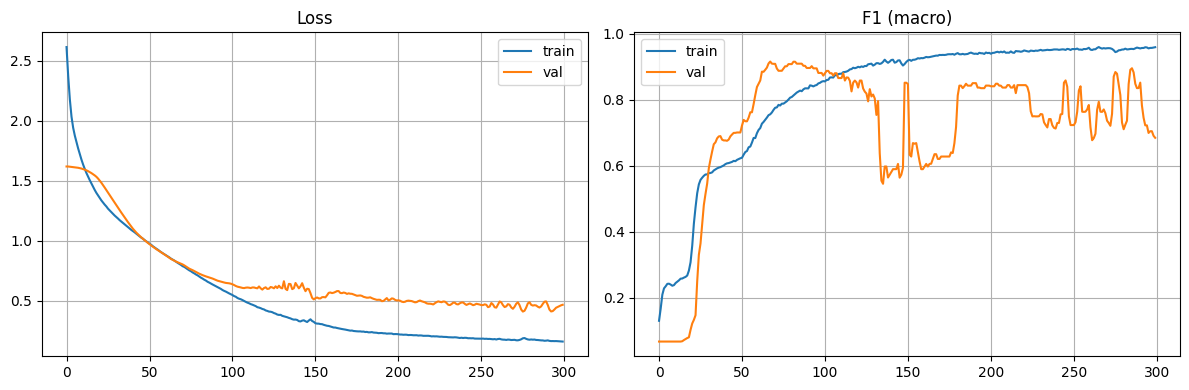

Training complete. Best val F1 = 0.9161 at epoch 68
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9714    0.9855        35
           1     1.0000    1.0000    1.0000        35
           2     0.9714    1.0000    0.9855        34
           3     1.0000    0.0588    0.1111        34
           4     0.5152    1.0000    0.6800        34

    accuracy                         0.8081       172
   macro avg     0.8973    0.8061    0.7524       172
weighted avg     0.8985    0.8081    0.7552       172

Overall Accuracy: 0.8081
Macro Precision: 0.8973
Macro Recall:    0.8061
Macro F1:        0.7524


 Train 7/51,	 User 6
Test user: 6, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|███████| 300/300 [04:01<00:00,  1.24epoch/s, TL=0.240, VL=0.512, VF=0.689, best VF=0.965, best Epoch=91]


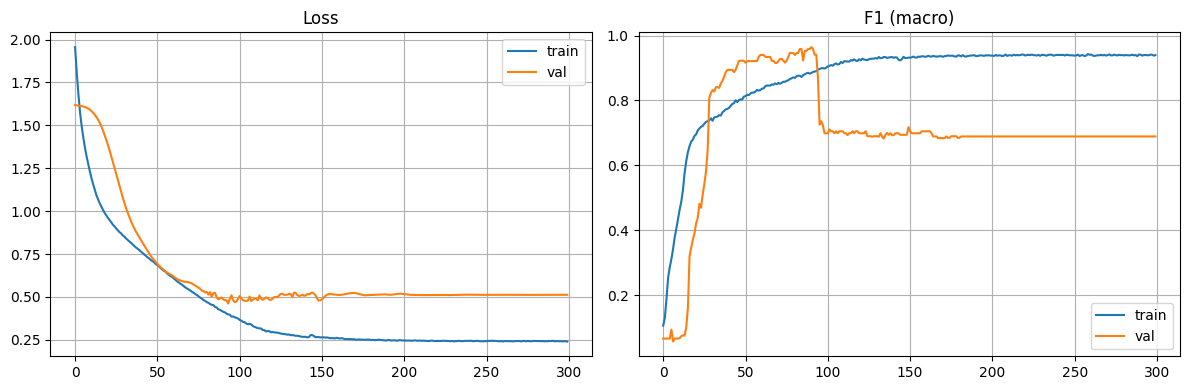

Training complete. Best val F1 = 0.9645 at epoch 91
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9706    0.9851        34
           1     1.0000    1.0000    1.0000        34
           2     0.9333    0.8235    0.8750        34
           3     0.0000    0.0000    0.0000        34
           4     0.4521    0.9706    0.6168        34

    accuracy                         0.7529       170
   macro avg     0.6771    0.7529    0.6954       170
weighted avg     0.6771    0.7529    0.6954       170

Overall Accuracy: 0.7529
Macro Precision: 0.6771
Macro Recall:    0.7529
Macro F1:        0.6954


 Train 8/51,	 User 7
Test user: 7, Val user: 43, Train users: 49


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Train windows: 8163, Val windows: 170, Test windows: 171
Class weights: tensor([0.9788, 0.9998, 1.0439, 0.9800, 1.0004])
Total trainable parameters: 13733


Training: 100%|███████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.179, VL=0.516, VF=0.715, best VF=0.940, best Epoch=90]


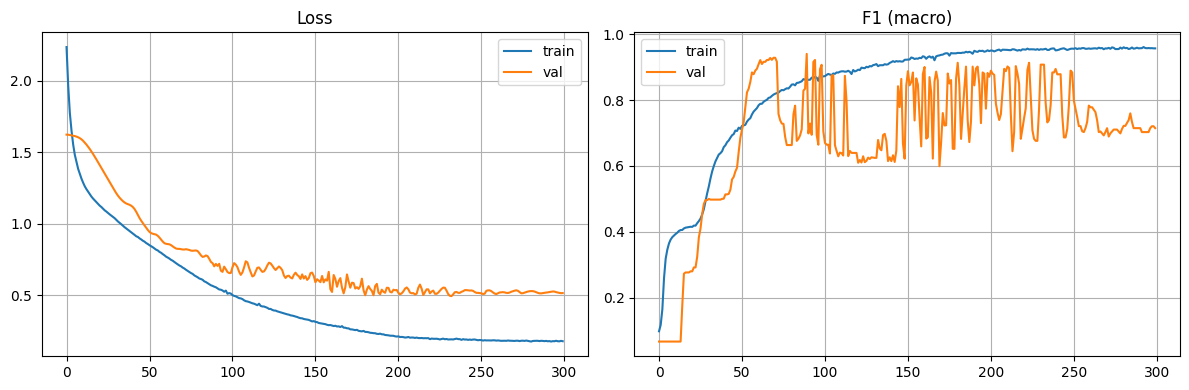

Training complete. Best val F1 = 0.9405 at epoch 90
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.6140    1.0000    0.7609        35
           1     0.9706    0.9706    0.9706        34
           2     1.0000    0.3824    0.5532        34
           3     0.9231    0.3529    0.5106        34
           4     0.6111    0.9706    0.7500        34

    accuracy                         0.7368       171
   macro avg     0.8238    0.7353    0.7091       171
weighted avg     0.8225    0.7368    0.7094       171

Overall Accuracy: 0.7368
Macro Precision: 0.8238
Macro Recall:    0.7353
Macro F1:        0.7091


 Train 9/51,	 User 8
Test user: 8, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.108, VL=0.198, VF=0.952, best VF=0.976, best Epoch=208]


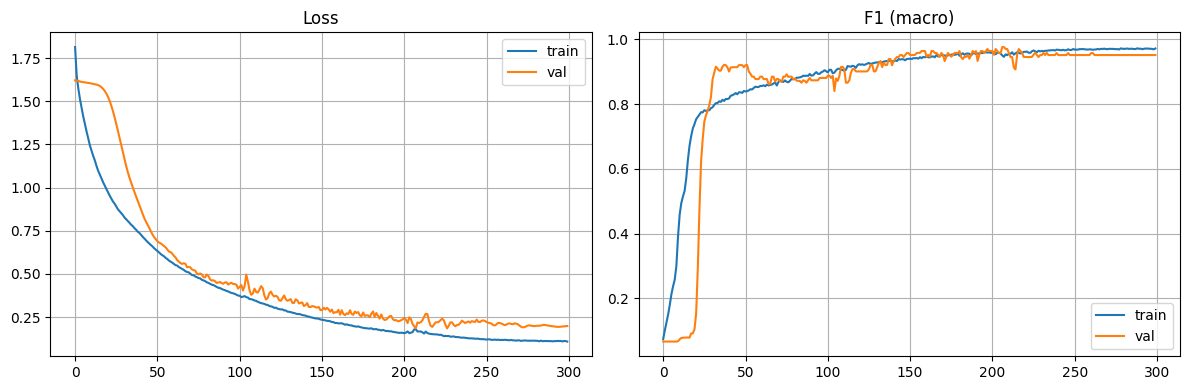

Training complete. Best val F1 = 0.9765 at epoch 208
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9412    0.9697        34
           1     1.0000    1.0000    1.0000        34
           2     0.9412    0.9412    0.9412        34
           3     0.5000    0.0588    0.1053        34
           4     0.5152    1.0000    0.6800        34

    accuracy                         0.7882       170
   macro avg     0.7913    0.7882    0.7392       170
weighted avg     0.7913    0.7882    0.7392       170

Overall Accuracy: 0.7882
Macro Precision: 0.7913
Macro Recall:    0.7882
Macro F1:        0.7392


 Train 10/51,	 User 9
Test user: 9, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|███████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.168, VL=0.349, VF=0.891, best VF=0.970, best Epoch=73]


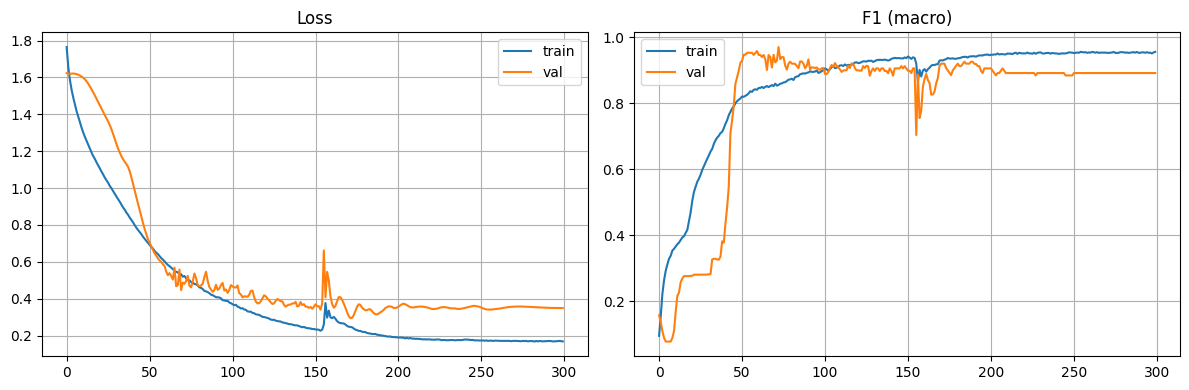

Training complete. Best val F1 = 0.9701 at epoch 73
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9444    1.0000    0.9714        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    0.6471    0.7857        34
           3     0.8000    0.9412    0.8649        34
           4     0.7368    0.8235    0.7778        34

    accuracy                         0.8824       170
   macro avg     0.8963    0.8824    0.8800       170
weighted avg     0.8963    0.8824    0.8800       170

Overall Accuracy: 0.8824
Macro Precision: 0.8963
Macro Recall:    0.8824
Macro F1:        0.8800


 Train 11/51,	 User 10
Test user: 10, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|███████| 300/300 [03:58<00:00,  1.26epoch/s, TL=0.098, VL=0.186, VF=0.957, best VF=0.976, best Epoch=73]


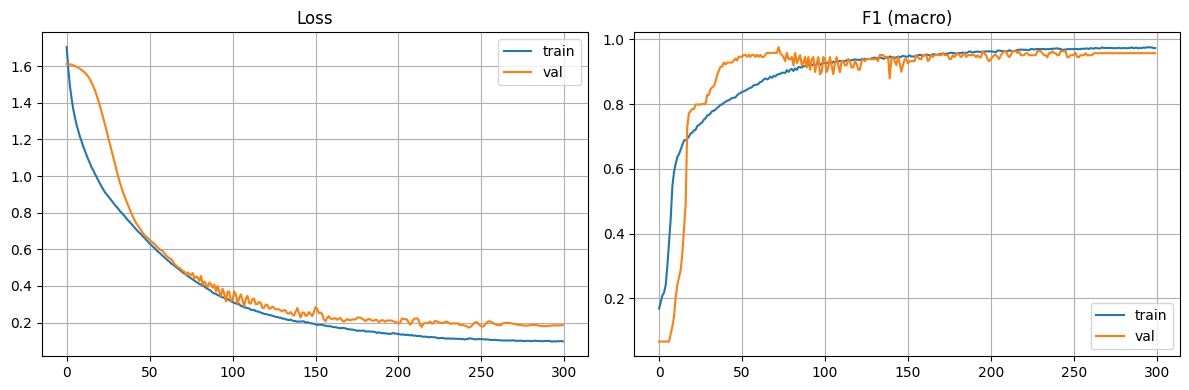

Training complete. Best val F1 = 0.9764 at epoch 73
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9189    1.0000    0.9577        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    0.9118    0.9538        34
           3     1.0000    1.0000    1.0000        34
           4     1.0000    1.0000    1.0000        34

    accuracy                         0.9824       170
   macro avg     0.9838    0.9824    0.9823       170
weighted avg     0.9838    0.9824    0.9823       170

Overall Accuracy: 0.9824
Macro Precision: 0.9838
Macro Recall:    0.9824
Macro F1:        0.9823


 Train 12/51,	 User 11
Test user: 11, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|███████| 300/300 [03:58<00:00,  1.26epoch/s, TL=0.192, VL=0.358, VF=0.911, best VF=0.971, best Epoch=98]


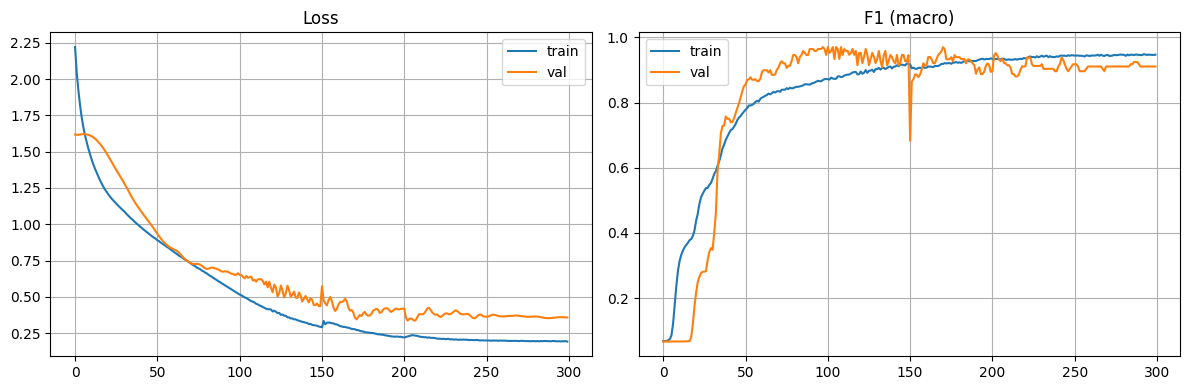

Training complete. Best val F1 = 0.9705 at epoch 98
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9714    1.0000    0.9855        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    0.9706    0.9851        34
           3     1.0000    0.8824    0.9375        34
           4     0.8947    1.0000    0.9444        34

    accuracy                         0.9706       170
   macro avg     0.9732    0.9706    0.9705       170
weighted avg     0.9732    0.9706    0.9705       170

Overall Accuracy: 0.9706
Macro Precision: 0.9732
Macro Recall:    0.9706
Macro F1:        0.9705


 Train 13/51,	 User 12
Test user: 12, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.090, VL=0.167, VF=0.965, best VF=0.988, best Epoch=145]


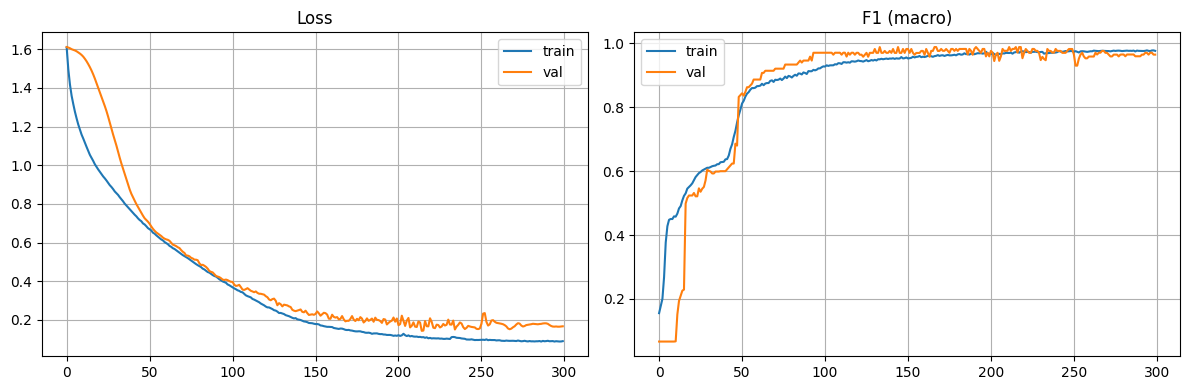

Training complete. Best val F1 = 0.9882 at epoch 145
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9714    1.0000    0.9855        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    0.9118    0.9538        34
           3     1.0000    1.0000    1.0000        34
           4     0.9444    1.0000    0.9714        34

    accuracy                         0.9824       170
   macro avg     0.9832    0.9824    0.9822       170
weighted avg     0.9832    0.9824    0.9822       170

Overall Accuracy: 0.9824
Macro Precision: 0.9832
Macro Recall:    0.9824
Macro F1:        0.9822


 Train 14/51,	 User 13
Test user: 13, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [04:00<00:00,  1.25epoch/s, TL=0.107, VL=0.148, VF=0.976, best VF=0.994, best Epoch=290]


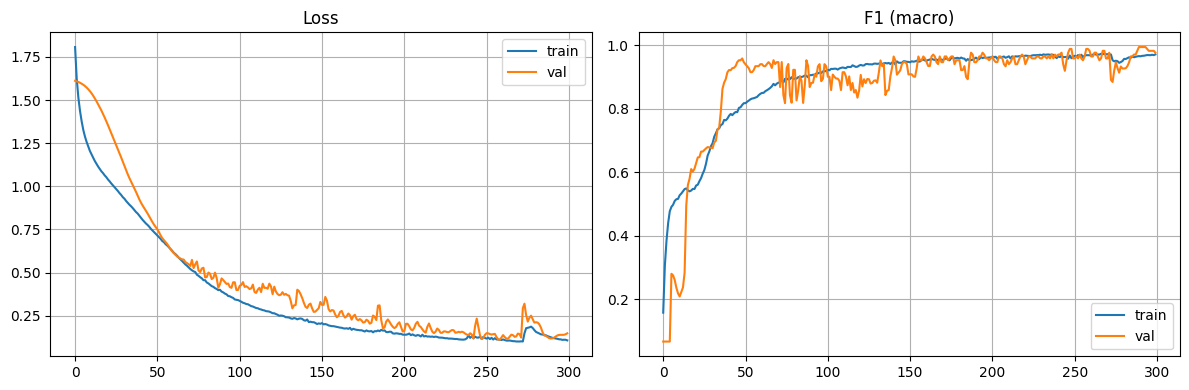

Training complete. Best val F1 = 0.9941 at epoch 290
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9333    0.8235    0.8750        34
           1     1.0000    0.7353    0.8475        34
           2     0.7391    1.0000    0.8500        34
           3     0.5000    1.0000    0.6667        34
           4     0.0000    0.0000    0.0000        34

    accuracy                         0.7118       170
   macro avg     0.6345    0.7118    0.6478       170
weighted avg     0.6345    0.7118    0.6478       170

Overall Accuracy: 0.7118
Macro Precision: 0.6345
Macro Recall:    0.7118
Macro F1:        0.6478


 Train 15/51,	 User 14
Test user: 14, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [04:00<00:00,  1.25epoch/s, TL=0.187, VL=0.411, VF=0.914, best VF=0.947, best Epoch=132]


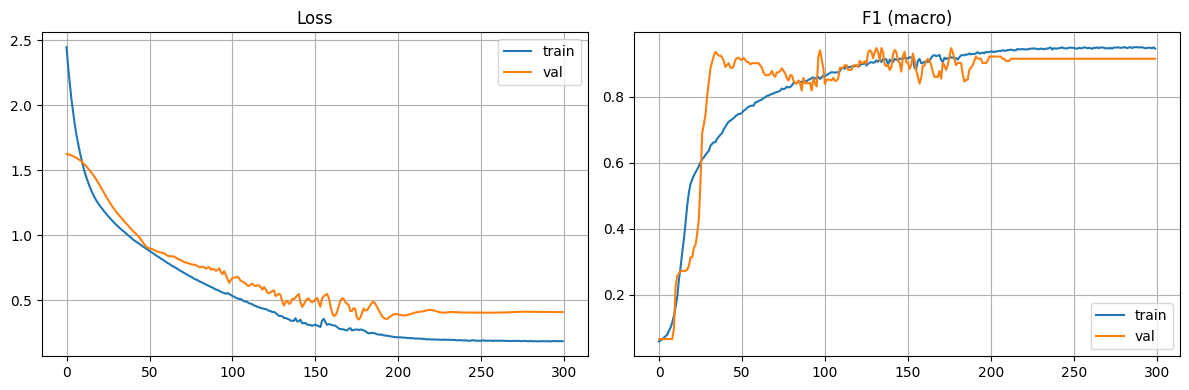

Training complete. Best val F1 = 0.9466 at epoch 132
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9714    1.0000    0.9855        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    0.9412    0.9697        34
           3     0.0000    0.0000    0.0000        34
           4     0.4928    1.0000    0.6602        34

    accuracy                         0.7882       170
   macro avg     0.6928    0.7882    0.7231       170
weighted avg     0.6928    0.7882    0.7231       170

Overall Accuracy: 0.7882
Macro Precision: 0.6928
Macro Recall:    0.7882
Macro F1:        0.7231


 Train 16/51,	 User 15
Test user: 15, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.192, VL=0.211, VF=0.964, best VF=0.970, best Epoch=104]


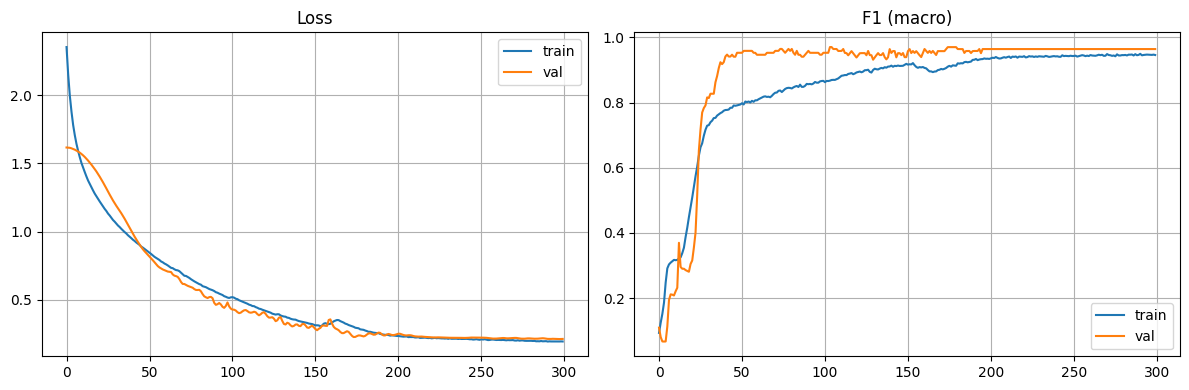

Training complete. Best val F1 = 0.9704 at epoch 104
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9706    0.9706    0.9706        34
           1     0.9189    1.0000    0.9577        34
           2     0.9667    0.8529    0.9062        34
           3     1.0000    1.0000    1.0000        34
           4     0.9714    1.0000    0.9855        34

    accuracy                         0.9647       170
   macro avg     0.9655    0.9647    0.9640       170
weighted avg     0.9655    0.9647    0.9640       170

Overall Accuracy: 0.9647
Macro Precision: 0.9655
Macro Recall:    0.9647
Macro F1:        0.9640


 Train 17/51,	 User 16
Test user: 16, Val user: 41, Train users: 49
Train windows: 8198, Val windows: 170, Test windows: 136
Class weights: tensor([0.9824, 0.9836, 1.0483, 0.9842, 1.0047])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.109, VL=0.213, VF=0.947, best VF=0.971, best Epoch=224]


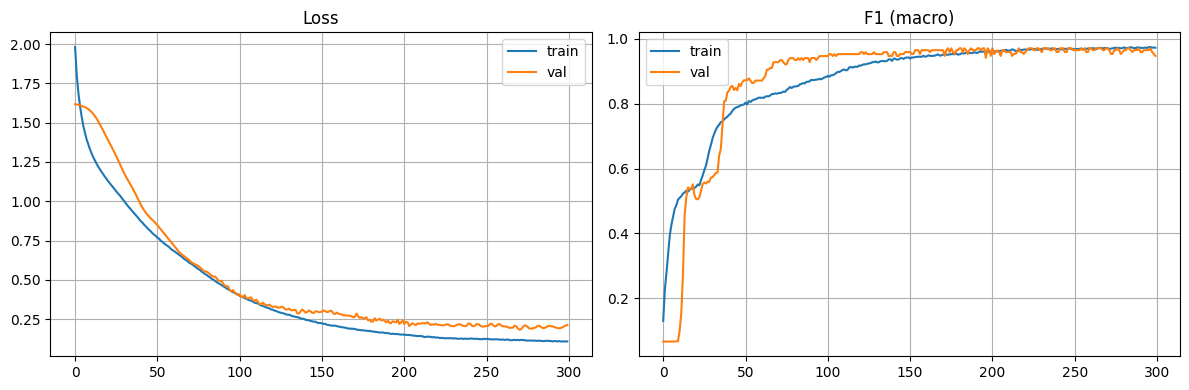

Training complete. Best val F1 = 0.9708 at epoch 224
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.8919    0.9706    0.9296        34
           2     1.0000    0.8235    0.9032        34
           3     0.9714    1.0000    0.9855        34
           4     0.9444    1.0000    0.9714        34

    accuracy                         0.9485       136
   macro avg     0.9519    0.9485    0.9474       136
weighted avg     0.9519    0.9485    0.9474       136

Overall Accuracy: 0.9485
Macro Precision: 0.9519
Macro Recall:    0.9485
Macro F1:        0.9474


 Train 18/51,	 User 17
Test user: 17, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|███████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.207, VL=0.437, VF=0.849, best VF=0.947, best Epoch=37]


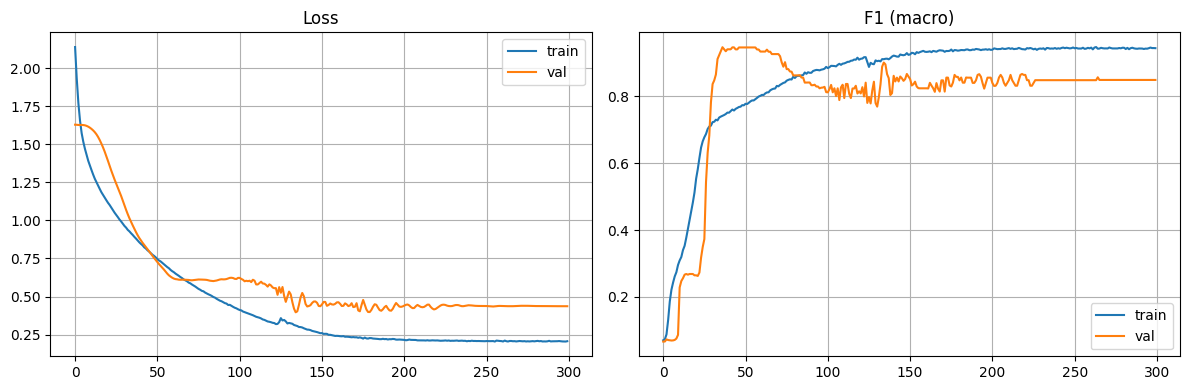

Training complete. Best val F1 = 0.9470 at epoch 37
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9697    0.9412    0.9552        34
           1     1.0000    1.0000    1.0000        34
           2     0.9429    0.9706    0.9565        34
           3     1.0000    1.0000    1.0000        34
           4     1.0000    1.0000    1.0000        34

    accuracy                         0.9824       170
   macro avg     0.9825    0.9824    0.9823       170
weighted avg     0.9825    0.9824    0.9823       170

Overall Accuracy: 0.9824
Macro Precision: 0.9825
Macro Recall:    0.9824
Macro F1:        0.9823


 Train 19/51,	 User 18
Test user: 18, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.196, VL=0.276, VF=0.941, best VF=0.976, best Epoch=107]


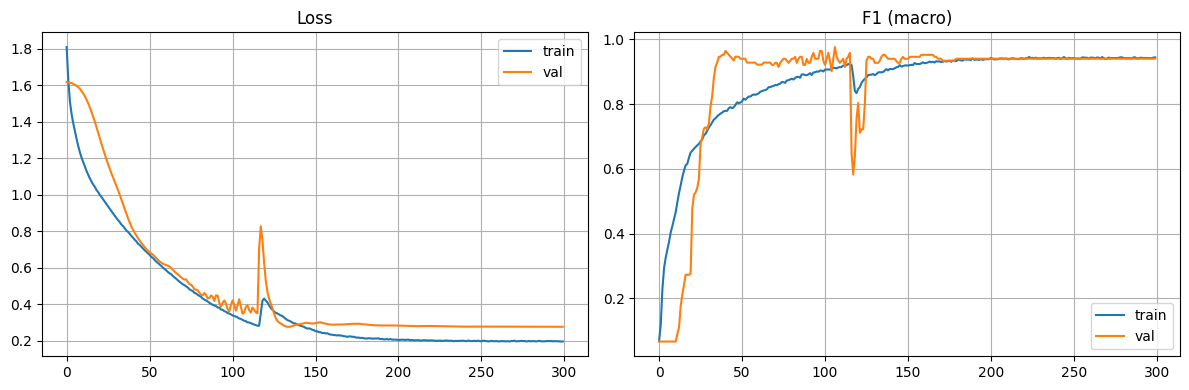

Training complete. Best val F1 = 0.9765 at epoch 107
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9697    0.9412    0.9552        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    0.7647    0.8667        34
           3     1.0000    0.9706    0.9851        34
           4     0.7727    1.0000    0.8718        34

    accuracy                         0.9353       170
   macro avg     0.9485    0.9353    0.9358       170
weighted avg     0.9485    0.9353    0.9358       170

Overall Accuracy: 0.9353
Macro Precision: 0.9485
Macro Recall:    0.9353
Macro F1:        0.9358


 Train 20/51,	 User 19
Test user: 19, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.145, VL=0.194, VF=0.970, best VF=0.982, best Epoch=214]


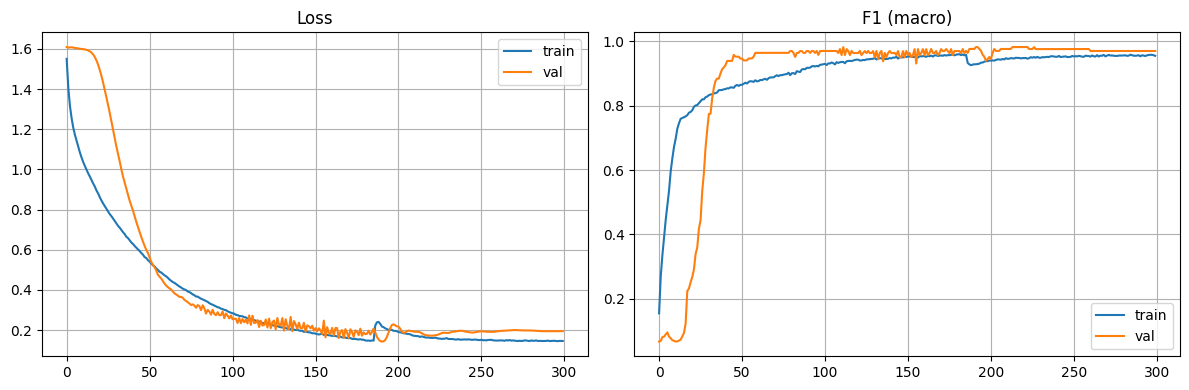

Training complete. Best val F1 = 0.9823 at epoch 214
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9189    1.0000    0.9577        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    0.8824    0.9375        34
           3     1.0000    1.0000    1.0000        34
           4     0.9714    1.0000    0.9855        34

    accuracy                         0.9765       170
   macro avg     0.9781    0.9765    0.9762       170
weighted avg     0.9781    0.9765    0.9762       170

Overall Accuracy: 0.9765
Macro Precision: 0.9781
Macro Recall:    0.9765
Macro F1:        0.9762


 Train 21/51,	 User 20
Test user: 20, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|███████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.175, VL=0.338, VF=0.868, best VF=0.935, best Epoch=92]


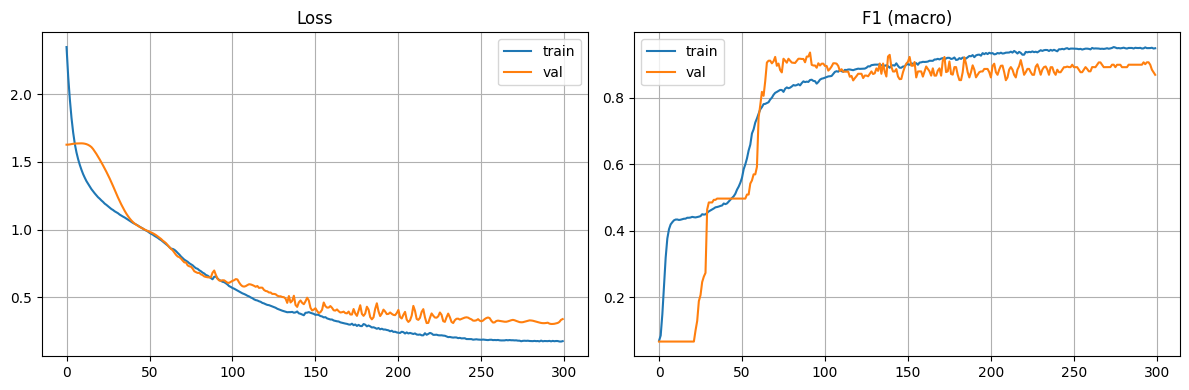

Training complete. Best val F1 = 0.9352 at epoch 92
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.8286    0.8529    0.8406        34
           1     0.9375    0.8824    0.9091        34
           2     0.7429    0.7647    0.7536        34
           3     1.0000    0.2353    0.3810        34
           4     0.5000    0.8824    0.6383        34

    accuracy                         0.7235       170
   macro avg     0.8018    0.7235    0.7045       170
weighted avg     0.8018    0.7235    0.7045       170

Overall Accuracy: 0.7235
Macro Precision: 0.8018
Macro Recall:    0.7235
Macro F1:        0.7045


 Train 22/51,	 User 21
Test user: 21, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.159, VL=0.317, VF=0.965, best VF=0.965, best Epoch=234]


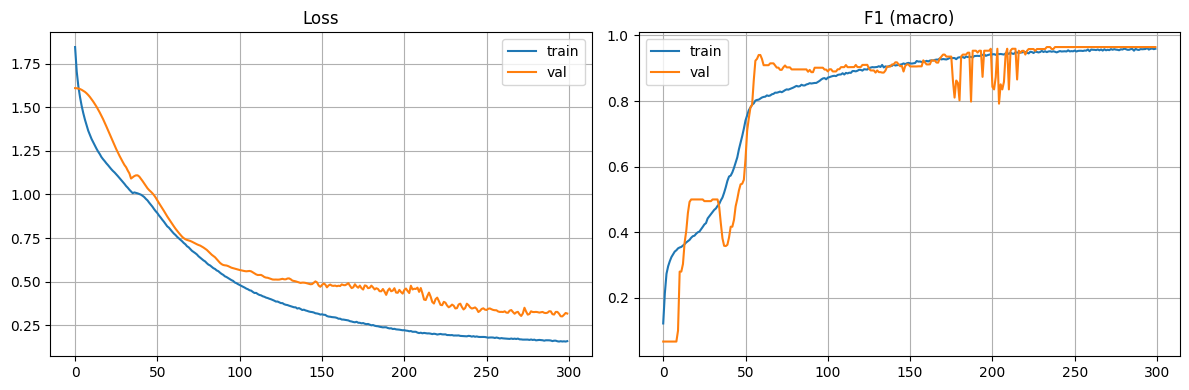

Training complete. Best val F1 = 0.9647 at epoch 234
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9167    0.6471    0.7586        34
           1     1.0000    1.0000    1.0000        34
           2     0.8800    0.6471    0.7458        34
           3     1.0000    0.2353    0.3810        34
           4     0.4304    1.0000    0.6018        34

    accuracy                         0.7059       170
   macro avg     0.8454    0.7059    0.6974       170
weighted avg     0.8454    0.7059    0.6974       170

Overall Accuracy: 0.7059
Macro Precision: 0.8454
Macro Recall:    0.7059
Macro F1:        0.6974


 Train 23/51,	 User 22
Test user: 22, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|███████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.222, VL=0.452, VF=0.845, best VF=0.959, best Epoch=64]


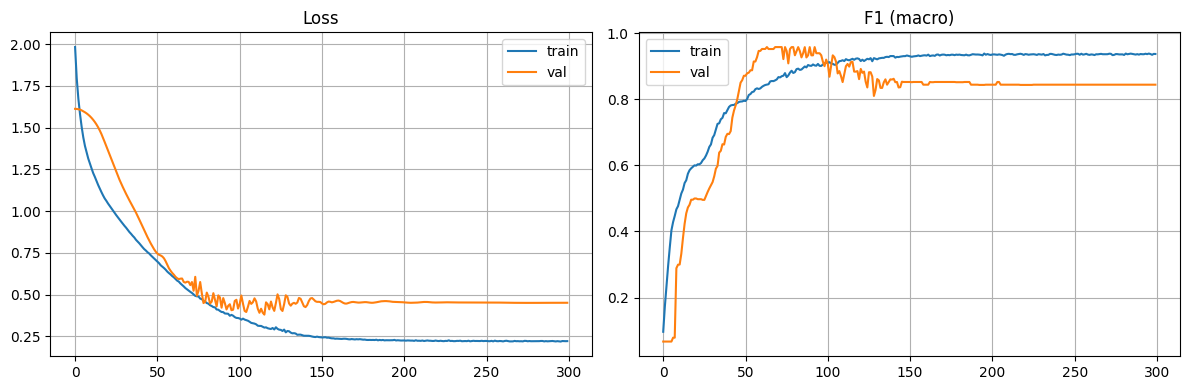

Training complete. Best val F1 = 0.9586 at epoch 64
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9714    1.0000    0.9855        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    0.9118    0.9538        34
           3     1.0000    0.5294    0.6923        34
           4     0.6538    1.0000    0.7907        34

    accuracy                         0.8882       170
   macro avg     0.9251    0.8882    0.8845       170
weighted avg     0.9251    0.8882    0.8845       170

Overall Accuracy: 0.8882
Macro Precision: 0.9251
Macro Recall:    0.8882
Macro F1:        0.8845


 Train 24/51,	 User 23
Test user: 23, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [04:00<00:00,  1.25epoch/s, TL=0.271, VL=0.342, VF=0.914, best VF=0.982, best Epoch=100]


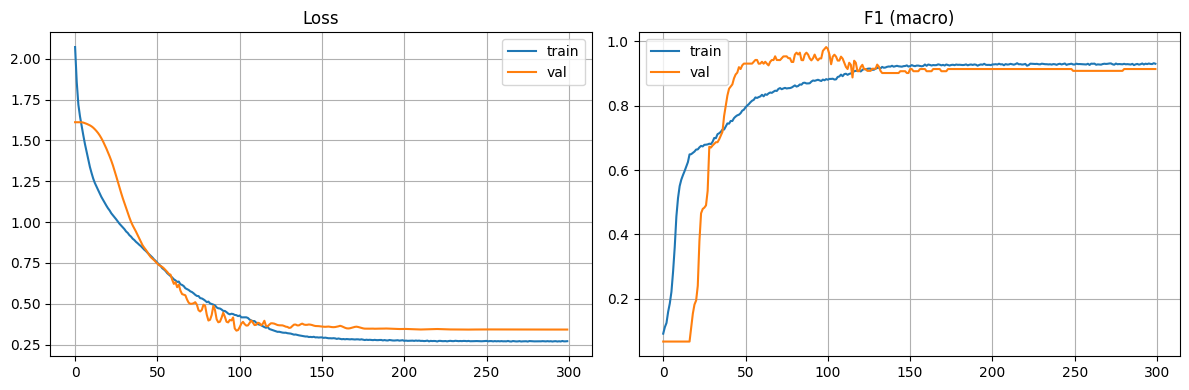

Training complete. Best val F1 = 0.9823 at epoch 100
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.6765    0.8070        34
           1     1.0000    1.0000    1.0000        34
           2     0.7556    1.0000    0.8608        34
           3     1.0000    1.0000    1.0000        34
           4     1.0000    1.0000    1.0000        34

    accuracy                         0.9353       170
   macro avg     0.9511    0.9353    0.9336       170
weighted avg     0.9511    0.9353    0.9336       170

Overall Accuracy: 0.9353
Macro Precision: 0.9511
Macro Recall:    0.9353
Macro F1:        0.9336


 Train 25/51,	 User 24
Test user: 24, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [04:00<00:00,  1.25epoch/s, TL=0.204, VL=0.294, VF=0.926, best VF=0.958, best Epoch=129]


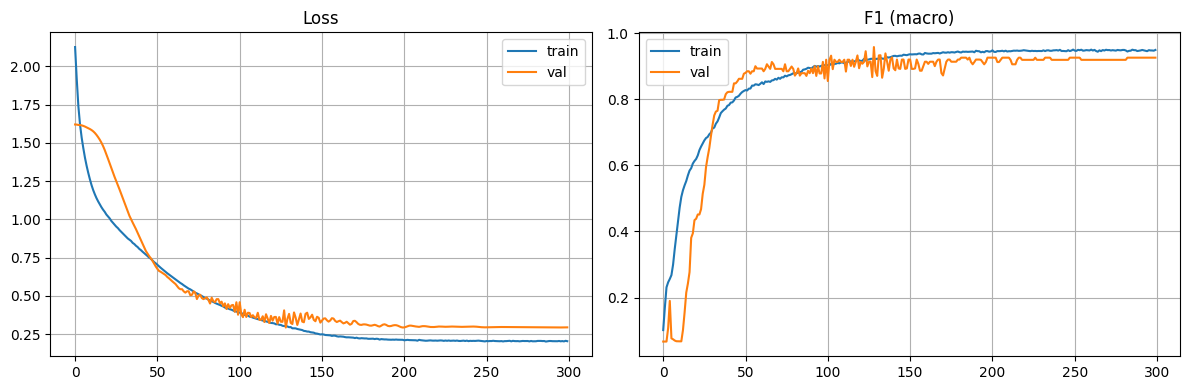

Training complete. Best val F1 = 0.9584 at epoch 129
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9167    0.9706    0.9429        34
           1     1.0000    1.0000    1.0000        34
           2     0.9394    0.9118    0.9254        34
           3     0.3913    0.2647    0.3158        34
           4     0.4318    0.5588    0.4872        34

    accuracy                         0.7412       170
   macro avg     0.7358    0.7412    0.7342       170
weighted avg     0.7358    0.7412    0.7342       170

Overall Accuracy: 0.7412
Macro Precision: 0.7358
Macro Recall:    0.7412
Macro F1:        0.7342


 Train 26/51,	 User 25
Test user: 25, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [04:00<00:00,  1.25epoch/s, TL=0.182, VL=0.292, VF=0.947, best VF=0.982, best Epoch=148]


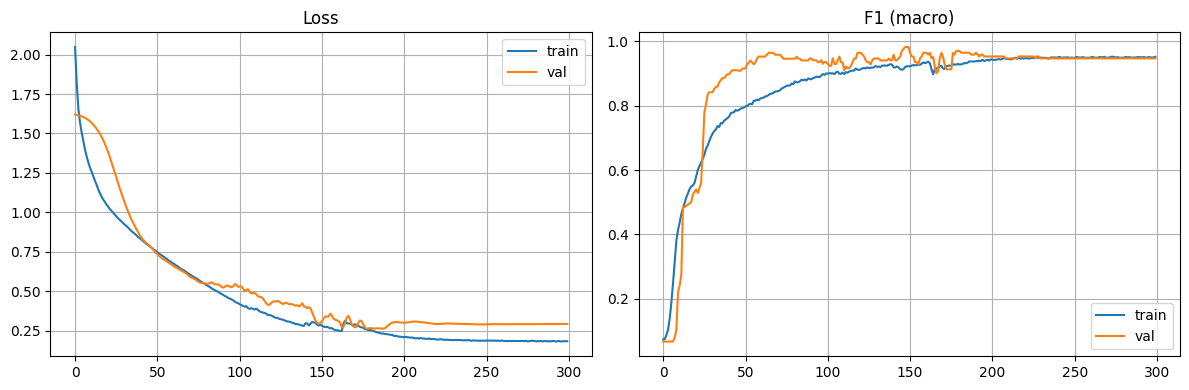

Training complete. Best val F1 = 0.9823 at epoch 148
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.8500    1.0000    0.9189        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    0.8235    0.9032        34
           3     1.0000    0.9412    0.9697        34
           4     0.9444    1.0000    0.9714        34

    accuracy                         0.9529       170
   macro avg     0.9589    0.9529    0.9527       170
weighted avg     0.9589    0.9529    0.9527       170

Overall Accuracy: 0.9529
Macro Precision: 0.9589
Macro Recall:    0.9529
Macro F1:        0.9527


 Train 27/51,	 User 26
Test user: 26, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [04:08<00:00,  1.21epoch/s, TL=0.152, VL=0.310, VF=0.899, best VF=0.915, best Epoch=153]


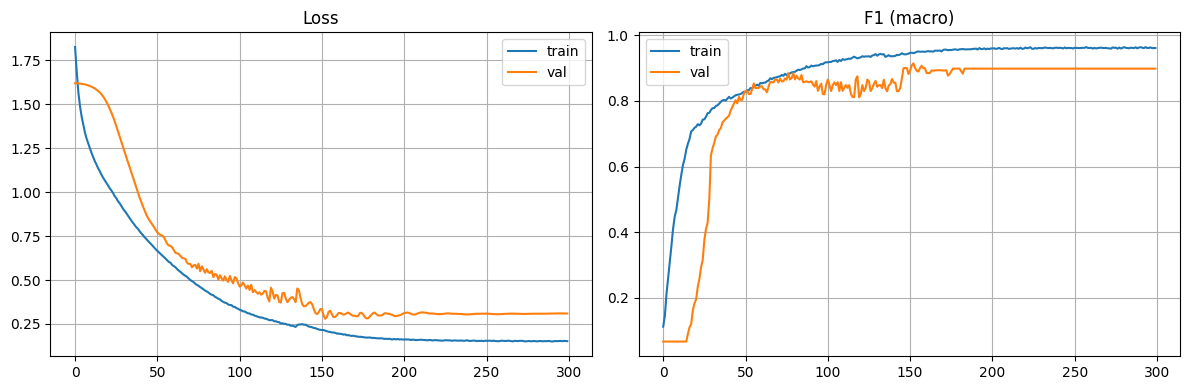

Training complete. Best val F1 = 0.9147 at epoch 153
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9412    0.9697        34
           1     1.0000    1.0000    1.0000        34
           2     0.9444    1.0000    0.9714        34
           3     1.0000    0.9412    0.9697        34
           4     0.9444    1.0000    0.9714        34

    accuracy                         0.9765       170
   macro avg     0.9778    0.9765    0.9765       170
weighted avg     0.9778    0.9765    0.9765       170

Overall Accuracy: 0.9765
Macro Precision: 0.9778
Macro Recall:    0.9765
Macro F1:        0.9765


 Train 28/51,	 User 27
Test user: 27, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.112, VL=0.136, VF=0.988, best VF=0.994, best Epoch=219]


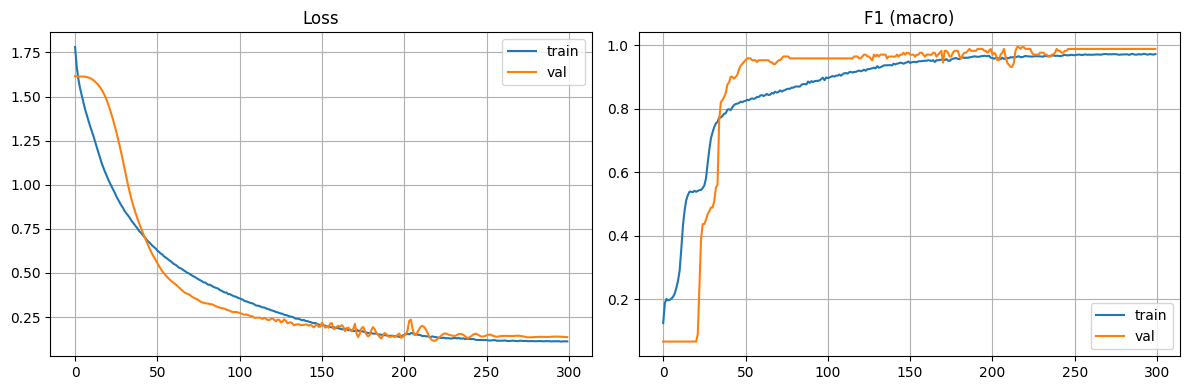

Training complete. Best val F1 = 0.9941 at epoch 219
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.7857    0.9706    0.8684        34
           1     1.0000    0.9118    0.9538        34
           2     0.9615    0.7353    0.8333        34
           3     0.9429    0.9706    0.9565        34
           4     0.9444    1.0000    0.9714        34

    accuracy                         0.9176       170
   macro avg     0.9269    0.9176    0.9167       170
weighted avg     0.9269    0.9176    0.9167       170

Overall Accuracy: 0.9176
Macro Precision: 0.9269
Macro Recall:    0.9176
Macro F1:        0.9167


 Train 29/51,	 User 28
Test user: 28, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:59<00:00,  1.26epoch/s, TL=0.139, VL=0.219, VF=0.952, best VF=0.982, best Epoch=184]


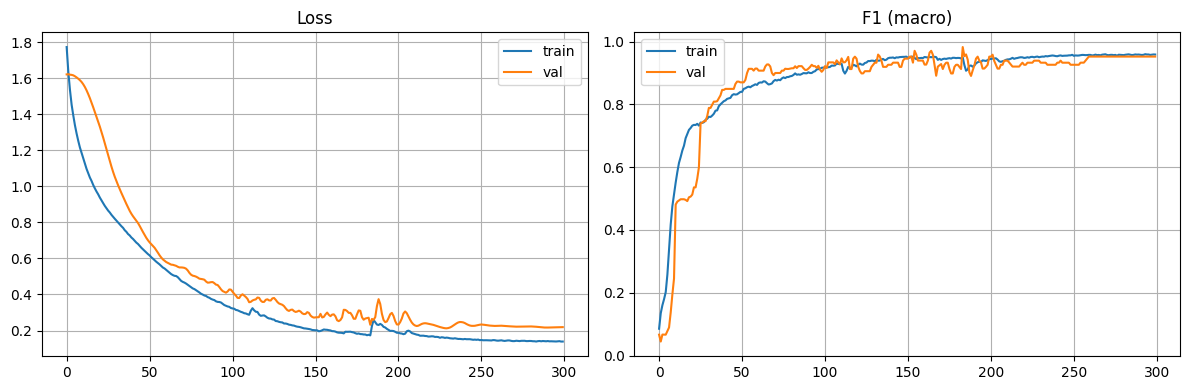

Training complete. Best val F1 = 0.9824 at epoch 184
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.4118    0.6176    0.4941        34
           1     1.0000    0.9412    0.9697        34
           2     0.3333    0.0294    0.0541        34
           3     0.4688    0.8824    0.6122        34
           4     0.0000    0.0000    0.0000        34

    accuracy                         0.4941       170
   macro avg     0.4428    0.4941    0.4260       170
weighted avg     0.4428    0.4941    0.4260       170

Overall Accuracy: 0.4941
Macro Precision: 0.4428
Macro Recall:    0.4941
Macro F1:        0.4260


 Train 30/51,	 User 29
Test user: 29, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [04:00<00:00,  1.25epoch/s, TL=0.149, VL=0.204, VF=0.976, best VF=0.976, best Epoch=133]


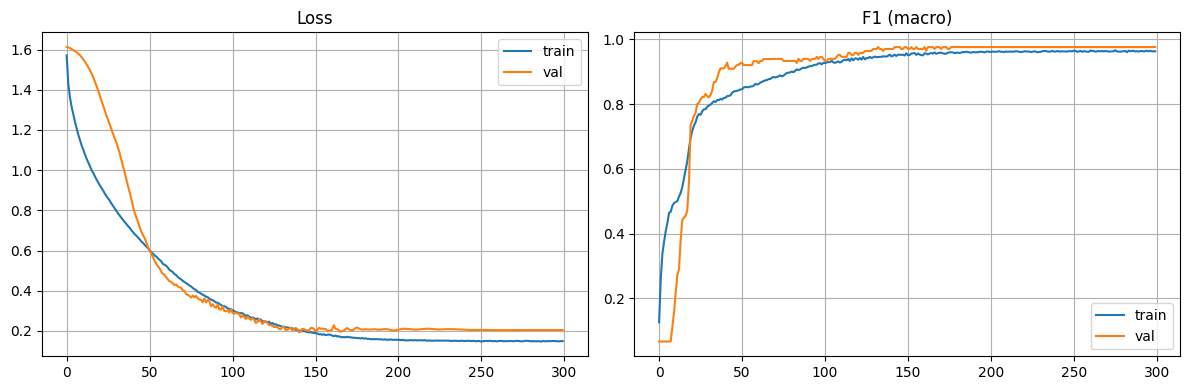

Training complete. Best val F1 = 0.9763 at epoch 133
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.8824    0.9375        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    1.0000    1.0000        34
           3     0.8889    0.2353    0.3721        34
           4     0.5238    0.9706    0.6804        34

    accuracy                         0.8176       170
   macro avg     0.8825    0.8176    0.7980       170
weighted avg     0.8825    0.8176    0.7980       170

Overall Accuracy: 0.8176
Macro Precision: 0.8825
Macro Recall:    0.8176
Macro F1:        0.7980


 Train 31/51,	 User 30
Test user: 30, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.130, VL=0.199, VF=0.940, best VF=0.965, best Epoch=167]


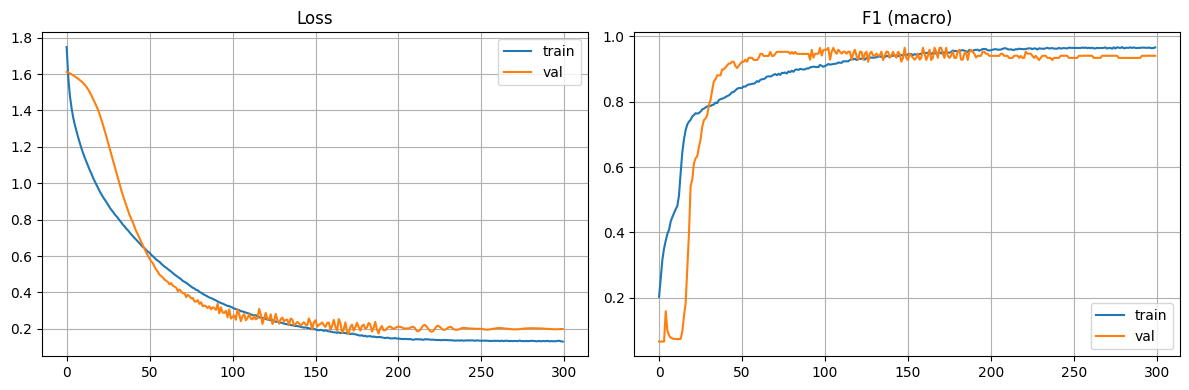

Training complete. Best val F1 = 0.9647 at epoch 167
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9706    0.9851        34
           1     1.0000    0.9412    0.9697        34
           2     0.9189    1.0000    0.9577        34
           3     1.0000    1.0000    1.0000        34
           4     1.0000    1.0000    1.0000        34

    accuracy                         0.9824       170
   macro avg     0.9838    0.9824    0.9825       170
weighted avg     0.9838    0.9824    0.9825       170

Overall Accuracy: 0.9824
Macro Precision: 0.9838
Macro Recall:    0.9824
Macro F1:        0.9825


 Train 32/51,	 User 31
Test user: 31, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.183, VL=0.345, VF=0.858, best VF=0.994, best Epoch=138]


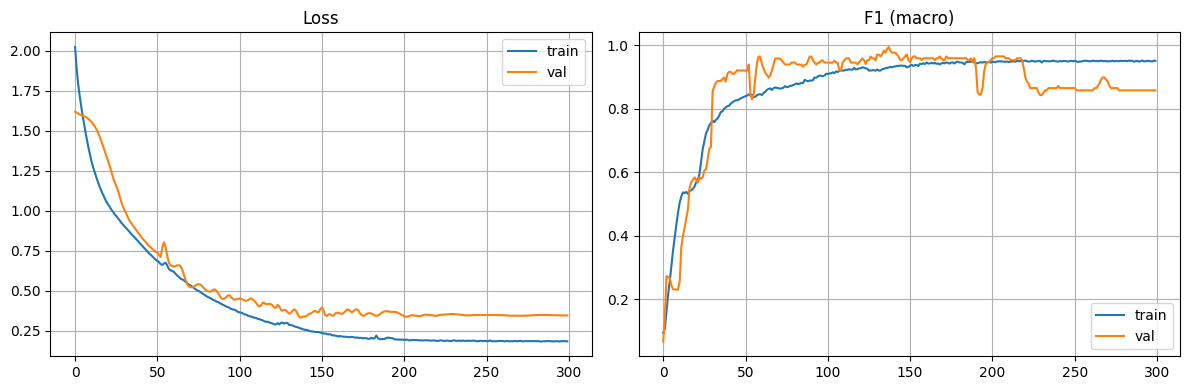

Training complete. Best val F1 = 0.9941 at epoch 138
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9167    0.9706    0.9429        34
           1     1.0000    1.0000    1.0000        34
           2     0.9583    0.6765    0.7931        34
           3     1.0000    0.2353    0.3810        34
           4     0.5000    1.0000    0.6667        34

    accuracy                         0.7765       170
   macro avg     0.8750    0.7765    0.7567       170
weighted avg     0.8750    0.7765    0.7567       170

Overall Accuracy: 0.7765
Macro Precision: 0.8750
Macro Recall:    0.7765
Macro F1:        0.7567


 Train 33/51,	 User 32
Test user: 32, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:58<00:00,  1.26epoch/s, TL=0.171, VL=0.329, VF=0.888, best VF=0.941, best Epoch=160]


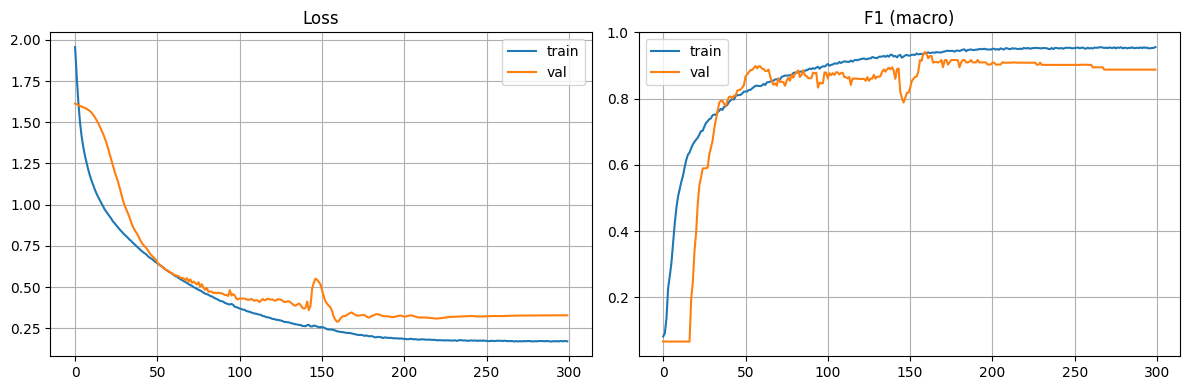

Training complete. Best val F1 = 0.9407 at epoch 160
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.8235    0.9032        34
           1     1.0000    1.0000    1.0000        34
           2     0.8500    1.0000    0.9189        34
           3     1.0000    1.0000    1.0000        34
           4     1.0000    1.0000    1.0000        34

    accuracy                         0.9647       170
   macro avg     0.9700    0.9647    0.9644       170
weighted avg     0.9700    0.9647    0.9644       170

Overall Accuracy: 0.9647
Macro Precision: 0.9700
Macro Recall:    0.9647
Macro F1:        0.9644


 Train 34/51,	 User 33
Test user: 33, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [04:00<00:00,  1.25epoch/s, TL=0.096, VL=0.171, VF=0.976, best VF=0.988, best Epoch=160]


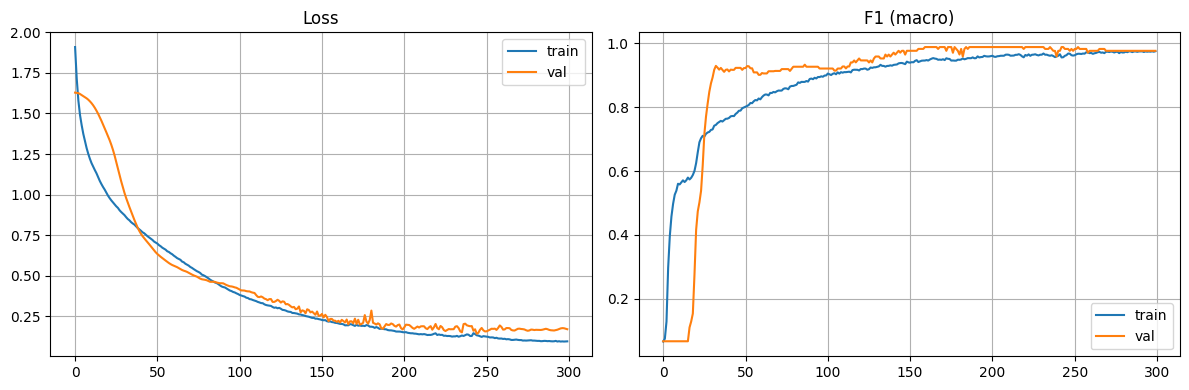

Training complete. Best val F1 = 0.9882 at epoch 160
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.8421    0.9412    0.8889        34
           1     1.0000    0.7647    0.8667        34
           2     0.8438    0.7941    0.8182        34
           3     0.7083    1.0000    0.8293        34
           4     0.7692    0.5882    0.6667        34

    accuracy                         0.8176       170
   macro avg     0.8327    0.8176    0.8139       170
weighted avg     0.8327    0.8176    0.8139       170

Overall Accuracy: 0.8176
Macro Precision: 0.8327
Macro Recall:    0.8176
Macro F1:        0.8139


 Train 35/51,	 User 34
Test user: 34, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [04:00<00:00,  1.25epoch/s, TL=0.138, VL=0.226, VF=0.970, best VF=0.988, best Epoch=123]


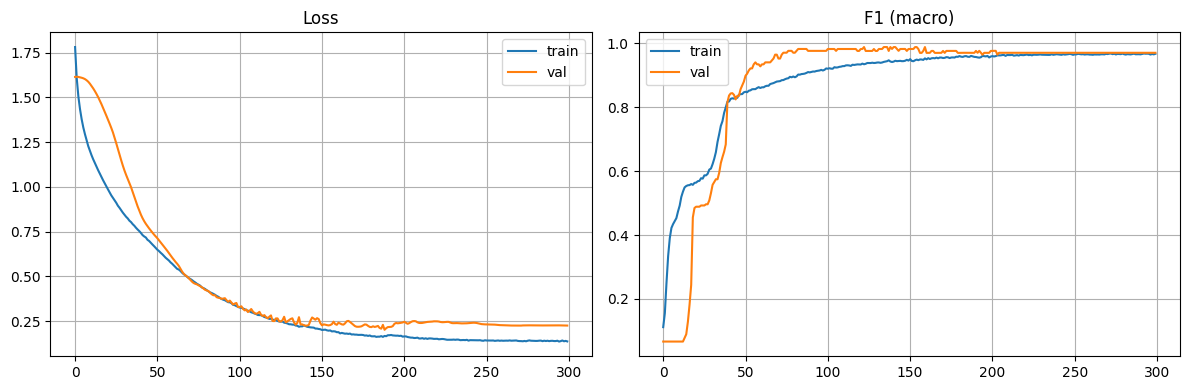

Training complete. Best val F1 = 0.9882 at epoch 123
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.6176    0.7636        34
           1     1.0000    0.9412    0.9697        34
           2     0.8095    1.0000    0.8947        34
           3     0.8966    0.7647    0.8254        34
           4     0.6957    0.9412    0.8000        34

    accuracy                         0.8529       170
   macro avg     0.8803    0.8529    0.8507       170
weighted avg     0.8803    0.8529    0.8507       170

Overall Accuracy: 0.8529
Macro Precision: 0.8803
Macro Recall:    0.8529
Macro F1:        0.8507


 Train 36/51,	 User 35
Test user: 35, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [04:00<00:00,  1.25epoch/s, TL=0.115, VL=0.132, VF=0.982, best VF=0.988, best Epoch=261]


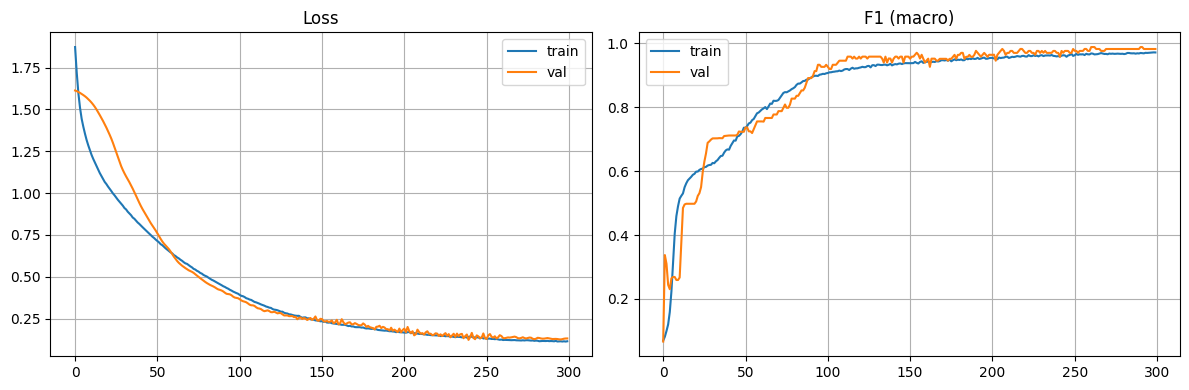

Training complete. Best val F1 = 0.9882 at epoch 261
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9429    0.9706    0.9565        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    0.9412    0.9697        34
           3     0.8649    0.9412    0.9014        34
           4     0.9375    0.8824    0.9091        34

    accuracy                         0.9471       170
   macro avg     0.9490    0.9471    0.9473       170
weighted avg     0.9490    0.9471    0.9473       170

Overall Accuracy: 0.9471
Macro Precision: 0.9490
Macro Recall:    0.9471
Macro F1:        0.9473


 Train 37/51,	 User 36
Test user: 36, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.184, VL=0.385, VF=0.863, best VF=0.952, best Epoch=106]


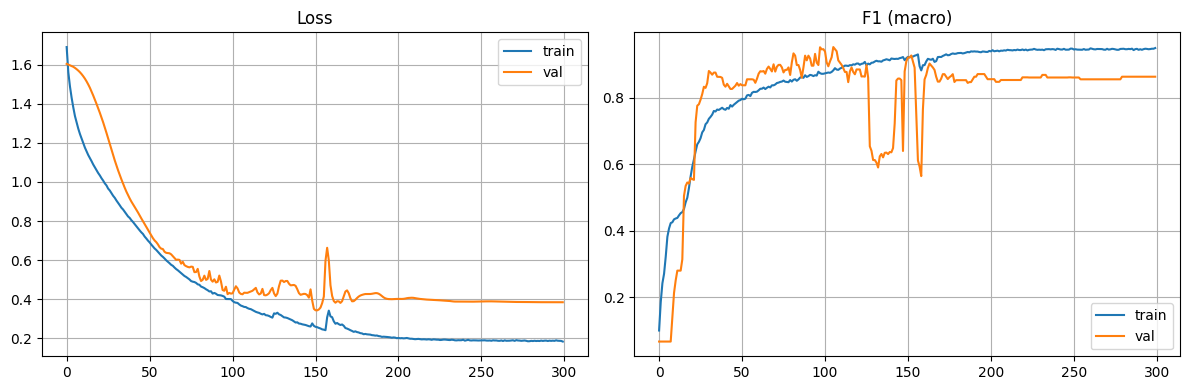

Training complete. Best val F1 = 0.9524 at epoch 106
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9118    0.9118    0.9118        34
           1     1.0000    0.9412    0.9697        34
           2     1.0000    0.0882    0.1622        34
           3     0.0000    0.0000    0.0000        34
           4     0.3366    1.0000    0.5037        34

    accuracy                         0.5882       170
   macro avg     0.6497    0.5882    0.5095       170
weighted avg     0.6497    0.5882    0.5095       170

Overall Accuracy: 0.5882
Macro Precision: 0.6497
Macro Recall:    0.5882
Macro F1:        0.5095


 Train 38/51,	 User 37
Test user: 37, Val user: 41, Train users: 49


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Train windows: 8198, Val windows: 170, Test windows: 136
Class weights: tensor([0.9824, 1.0040, 1.0260, 0.9842, 1.0047])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:59<00:00,  1.26epoch/s, TL=0.121, VL=0.231, VF=0.959, best VF=0.982, best Epoch=208]


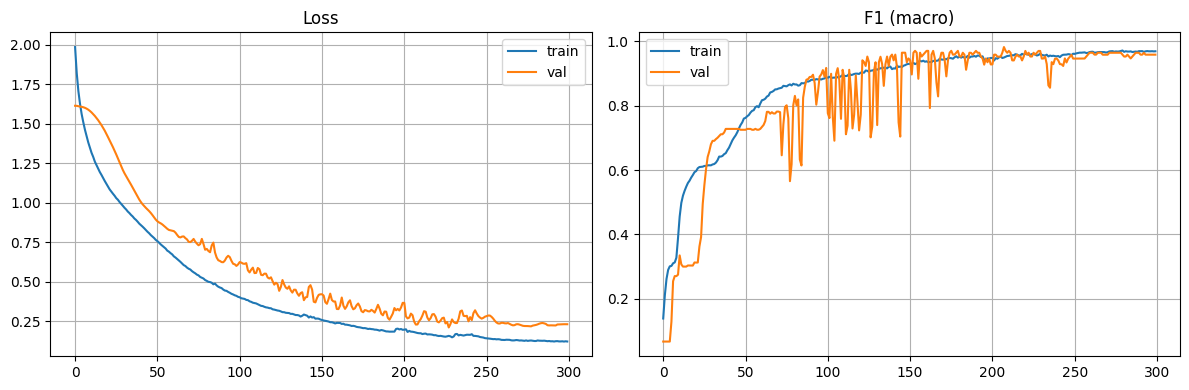

Training complete. Best val F1 = 0.9823 at epoch 208
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.7647    0.8667        34
           1     0.9444    1.0000    0.9714        34
           2     0.0000    0.0000    0.0000         0
           3     0.3333    0.0294    0.0541        34
           4     0.5000    0.9706    0.6600        34

    accuracy                         0.6912       136
   macro avg     0.5556    0.5529    0.5104       136
weighted avg     0.6944    0.6912    0.6380       136

Overall Accuracy: 0.6912
Macro Precision: 0.5556
Macro Recall:    0.5529
Macro F1:        0.5104


 Train 39/51,	 User 38
Test user: 38, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.177, VL=0.221, VF=0.945, best VF=0.982, best Epoch=113]


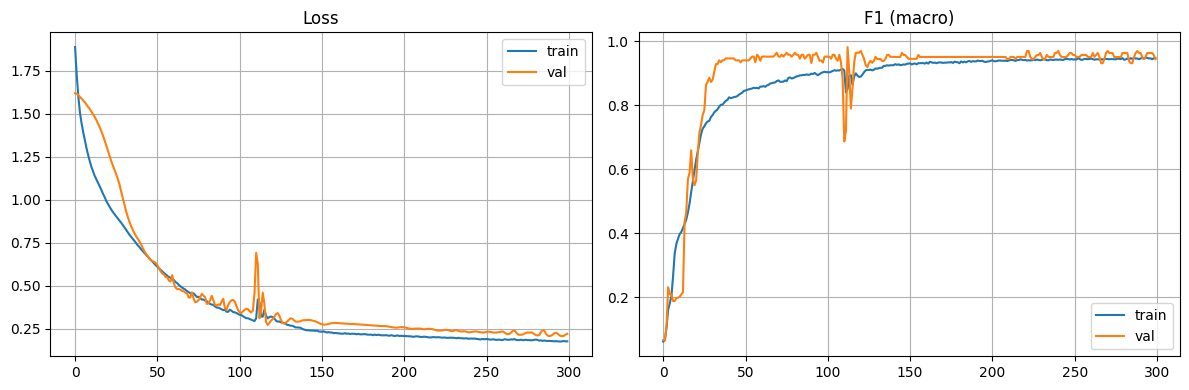

Training complete. Best val F1 = 0.9823 at epoch 113
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.6562    0.6176    0.6364        34
           1     0.0000    0.0000    0.0000        34
           2     0.3030    0.2941    0.2985        34
           3     0.4789    1.0000    0.6476        34
           4     0.0588    0.0588    0.0588        34

    accuracy                         0.3941       170
   macro avg     0.2994    0.3941    0.3283       170
weighted avg     0.2994    0.3941    0.3283       170

Overall Accuracy: 0.3941
Macro Precision: 0.2994
Macro Recall:    0.3941
Macro F1:        0.3283


 Train 40/51,	 User 39
Test user: 39, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.179, VL=0.228, VF=0.941, best VF=1.000, best Epoch=132]


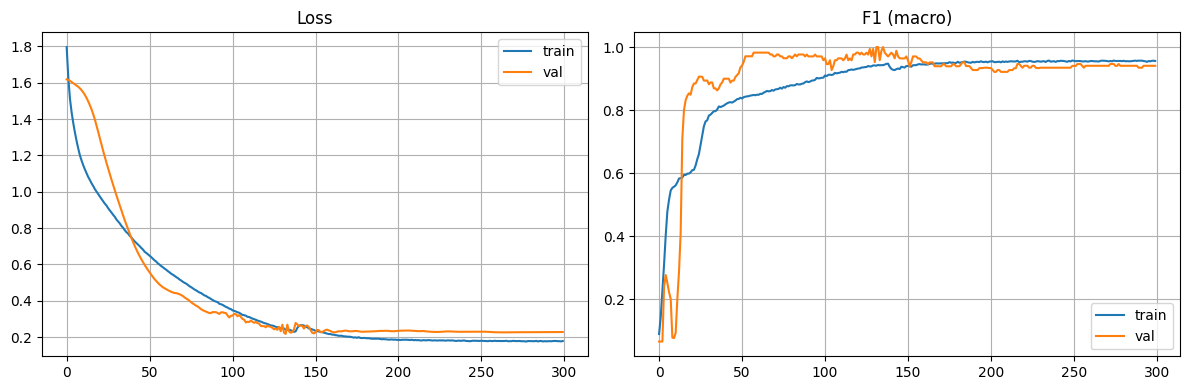

Training complete. Best val F1 = 1.0000 at epoch 132
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.6182    1.0000    0.7640        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    0.3235    0.4889        34
           3     0.9714    1.0000    0.9855        34
           4     0.9714    1.0000    0.9855        34

    accuracy                         0.8647       170
   macro avg     0.9122    0.8647    0.8448       170
weighted avg     0.9122    0.8647    0.8448       170

Overall Accuracy: 0.8647
Macro Precision: 0.9122
Macro Recall:    0.8647
Macro F1:        0.8448


 Train 41/51,	 User 40
Test user: 40, Val user: 41, Train users: 49
Train windows: 8232, Val windows: 170, Test windows: 102
Class weights: tensor([0.9865, 1.0082, 1.0303, 0.9882, 0.9882])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [04:01<00:00,  1.24epoch/s, TL=0.125, VL=0.163, VF=0.988, best VF=0.994, best Epoch=208]


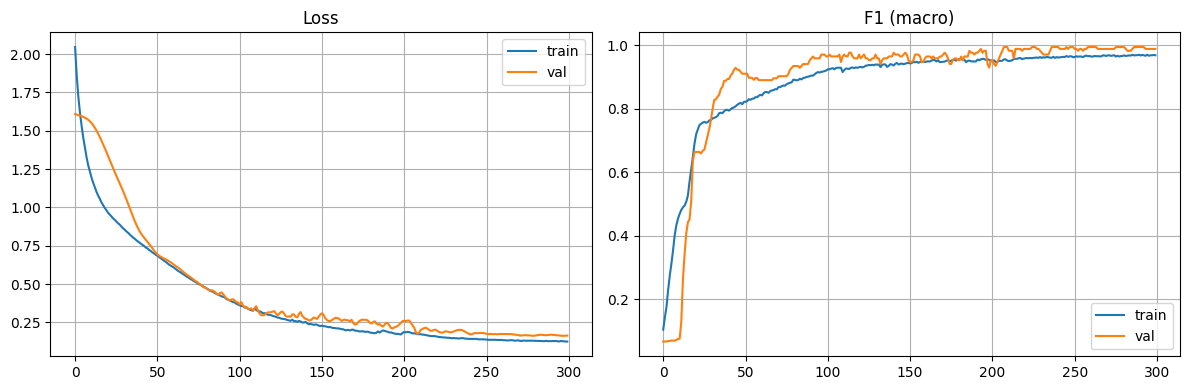

Training complete. Best val F1 = 0.9941 at epoch 208
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        34
           1     1.0000    1.0000    1.0000        34
           3     0.0000    0.0000    0.0000        34
           4     0.0000    0.0000    0.0000         0

    accuracy                         0.3333       102
   macro avg     0.2500    0.2500    0.2500       102
weighted avg     0.3333    0.3333    0.3333       102

Overall Accuracy: 0.3333
Macro Precision: 0.2500
Macro Recall:    0.2500
Macro F1:        0.2500


 Train 42/51,	 User 41
Test user: 41, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|███████| 300/300 [04:00<00:00,  1.25epoch/s, TL=0.183, VL=0.406, VF=0.756, best VF=0.971, best Epoch=66]


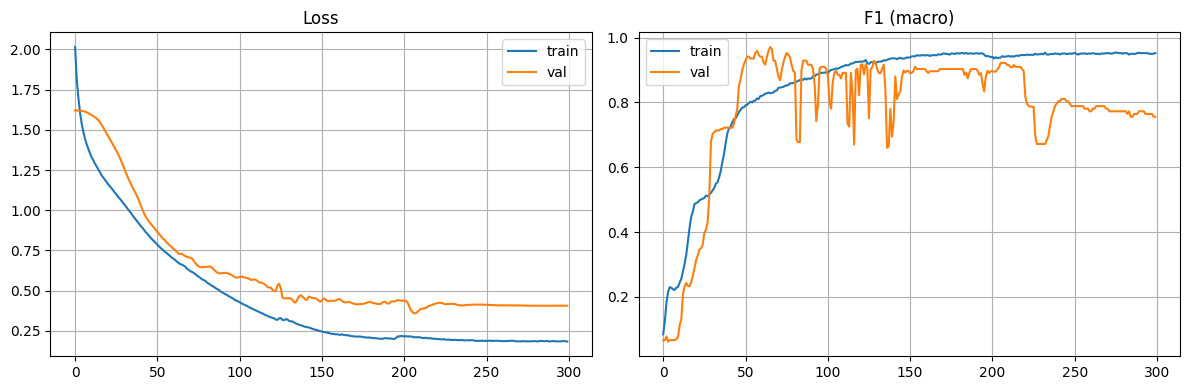

Training complete. Best val F1 = 0.9706 at epoch 66
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9118    0.9538        34
           1     1.0000    1.0000    1.0000        34
           2     0.9189    1.0000    0.9577        34
           3     1.0000    0.2059    0.3415        34
           4     0.5574    1.0000    0.7158        34

    accuracy                         0.8235       170
   macro avg     0.8953    0.8235    0.7938       170
weighted avg     0.8953    0.8235    0.7938       170

Overall Accuracy: 0.8235
Macro Precision: 0.8953
Macro Recall:    0.8235
Macro F1:        0.7938


 Train 43/51,	 User 42
Test user: 42, Val user: 41, Train users: 49
Train windows: 8198, Val windows: 170, Test windows: 136
Class weights: tensor([0.9824, 1.0040, 1.0260, 0.9842, 1.0047])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [04:01<00:00,  1.24epoch/s, TL=0.146, VL=0.401, VF=0.893, best VF=0.936, best Epoch=249]


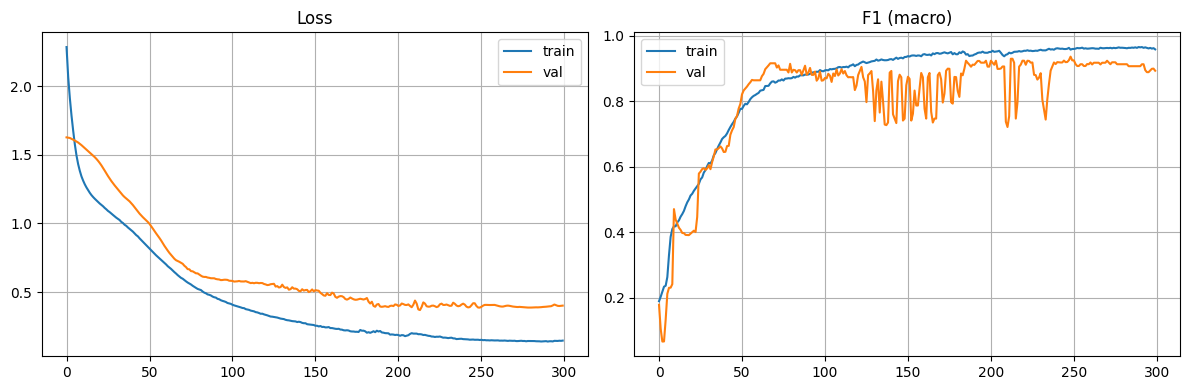

Training complete. Best val F1 = 0.9358 at epoch 249
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.5000    0.6667        34
           1     1.0000    1.0000    1.0000        34
           2     0.0000    0.0000    0.0000         0
           3     0.9167    0.9706    0.9429        34
           4     0.7442    0.9412    0.8312        34

    accuracy                         0.8529       136
   macro avg     0.7322    0.6824    0.6881       136
weighted avg     0.9152    0.8529    0.8602       136

Overall Accuracy: 0.8529
Macro Precision: 0.7322
Macro Recall:    0.6824
Macro F1:        0.6881


 Train 44/51,	 User 43
Test user: 43, Val user: 41, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [04:00<00:00,  1.25epoch/s, TL=0.185, VL=0.253, VF=0.959, best VF=0.965, best Epoch=181]


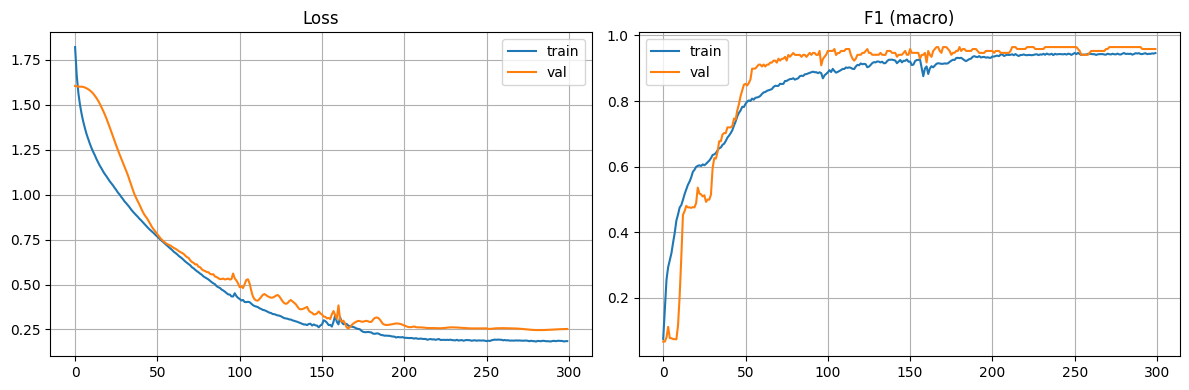

Training complete. Best val F1 = 0.9647 at epoch 181
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.7907    1.0000    0.8831        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    0.7059    0.8276        34
           3     0.9714    1.0000    0.9855        34
           4     1.0000    1.0000    1.0000        34

    accuracy                         0.9412       170
   macro avg     0.9524    0.9412    0.9392       170
weighted avg     0.9524    0.9412    0.9392       170

Overall Accuracy: 0.9412
Macro Precision: 0.9524
Macro Recall:    0.9412
Macro F1:        0.9392


 Train 45/51,	 User 44
Test user: 44, Val user: 41, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [04:00<00:00,  1.25epoch/s, TL=0.138, VL=0.246, VF=0.959, best VF=0.982, best Epoch=127]


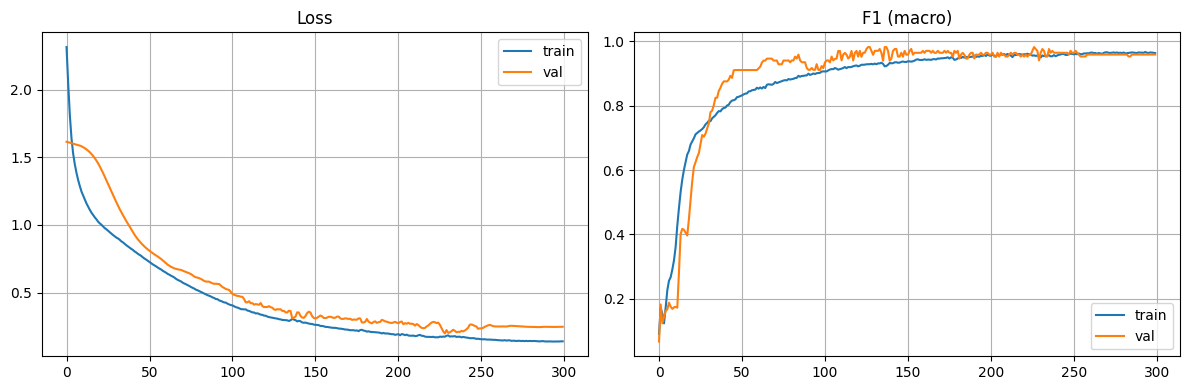

Training complete. Best val F1 = 0.9823 at epoch 127
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9706    0.9851        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    1.0000    1.0000        34
           3     1.0000    0.6765    0.8070        34
           4     0.7391    1.0000    0.8500        34

    accuracy                         0.9294       170
   macro avg     0.9478    0.9294    0.9284       170
weighted avg     0.9478    0.9294    0.9284       170

Overall Accuracy: 0.9294
Macro Precision: 0.9478
Macro Recall:    0.9294
Macro F1:        0.9284


 Train 46/51,	 User 45
Test user: 45, Val user: 41, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [04:00<00:00,  1.25epoch/s, TL=0.153, VL=0.234, VF=0.935, best VF=0.971, best Epoch=215]


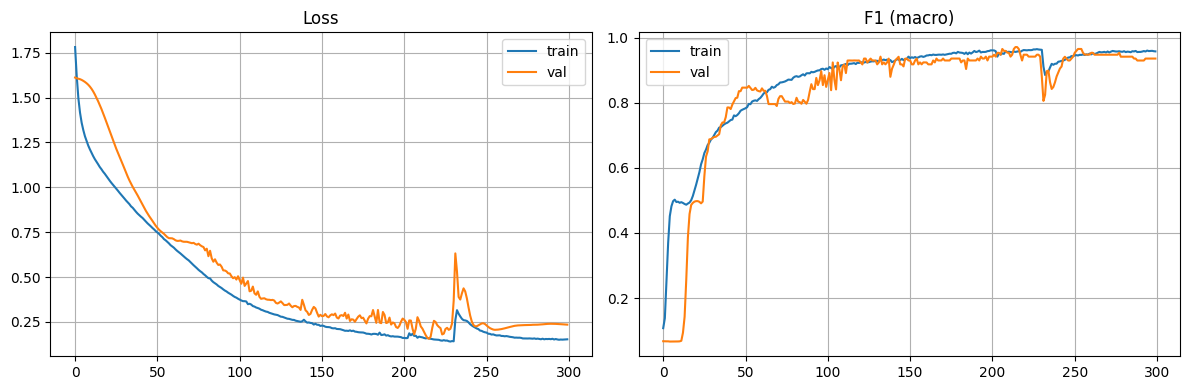

Training complete. Best val F1 = 0.9708 at epoch 215
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.8611    0.9118    0.8857        34
           1     0.9394    0.9118    0.9254        34
           2     0.8621    0.7353    0.7937        34
           3     1.0000    0.9706    0.9851        34
           4     0.8718    1.0000    0.9315        34

    accuracy                         0.9059       170
   macro avg     0.9069    0.9059    0.9043       170
weighted avg     0.9069    0.9059    0.9043       170

Overall Accuracy: 0.9059
Macro Precision: 0.9069
Macro Recall:    0.9059
Macro F1:        0.9043


 Train 47/51,	 User 46
Test user: 46, Val user: 41, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.109, VL=0.204, VF=0.941, best VF=0.982, best Epoch=130]


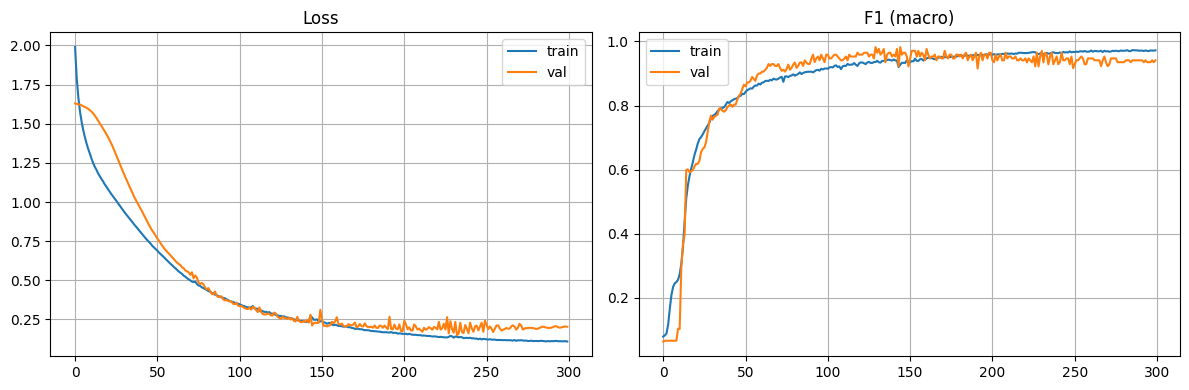

Training complete. Best val F1 = 0.9823 at epoch 130
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.8966    0.7647    0.8254        34
           1     1.0000    0.7353    0.8475        34
           2     0.8571    0.8824    0.8696        34
           3     0.7000    0.6176    0.6562        34
           4     0.6471    0.9706    0.7765        34

    accuracy                         0.7941       170
   macro avg     0.8202    0.7941    0.7950       170
weighted avg     0.8202    0.7941    0.7950       170

Overall Accuracy: 0.7941
Macro Precision: 0.8202
Macro Recall:    0.7941
Macro F1:        0.7950


 Train 48/51,	 User 47
Test user: 47, Val user: 41, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|███████| 300/300 [03:58<00:00,  1.26epoch/s, TL=0.196, VL=0.375, VF=0.814, best VF=0.908, best Epoch=39]


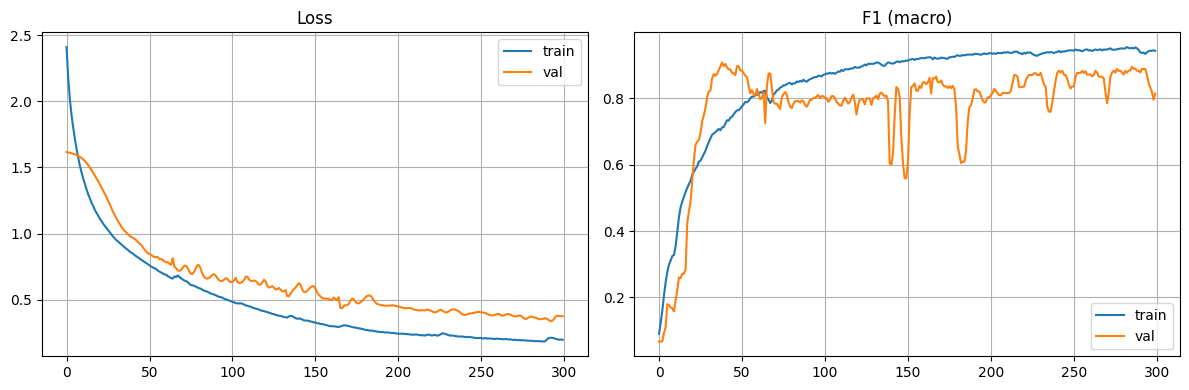

Training complete. Best val F1 = 0.9079 at epoch 39
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9412    0.9412    0.9412        34
           1     1.0000    1.0000    1.0000        34
           2     0.9412    0.9412    0.9412        34
           3     0.0000    0.0000    0.0000        34
           4     0.5000    1.0000    0.6667        34

    accuracy                         0.7765       170
   macro avg     0.6765    0.7765    0.7098       170
weighted avg     0.6765    0.7765    0.7098       170

Overall Accuracy: 0.7765
Macro Precision: 0.6765
Macro Recall:    0.7765
Macro F1:        0.7098


 Train 49/51,	 User 48
Test user: 48, Val user: 41, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.135, VL=0.269, VF=0.917, best VF=0.959, best Epoch=123]


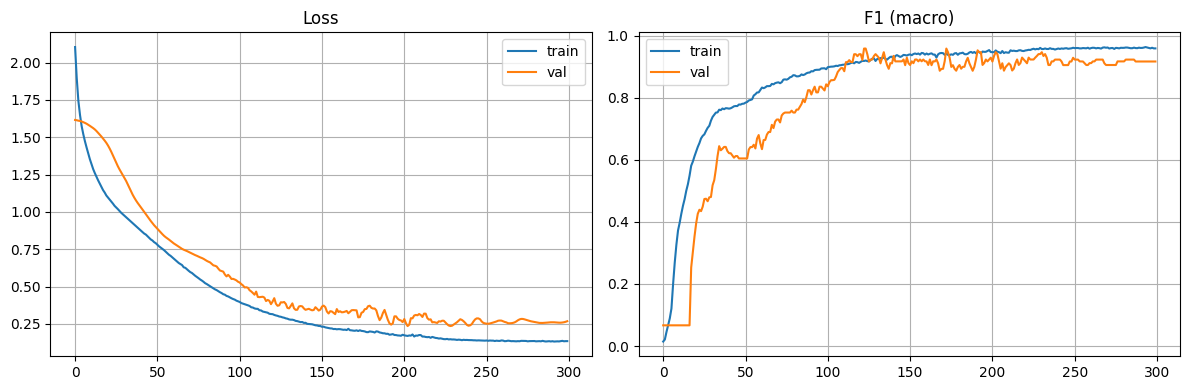

Training complete. Best val F1 = 0.9585 at epoch 123
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.7297    0.7941    0.7606        34
           1     1.0000    0.9706    0.9851        34
           2     0.7826    0.5294    0.6316        34
           3     0.5000    1.0000    0.6667        34
           4     0.8889    0.2353    0.3721        34

    accuracy                         0.7059       170
   macro avg     0.7802    0.7059    0.6832       170
weighted avg     0.7802    0.7059    0.6832       170

Overall Accuracy: 0.7059
Macro Precision: 0.7802
Macro Recall:    0.7059
Macro F1:        0.6832


 Train 50/51,	 User 49
Test user: 49, Val user: 41, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [04:00<00:00,  1.25epoch/s, TL=0.158, VL=0.204, VF=0.959, best VF=0.959, best Epoch=300]


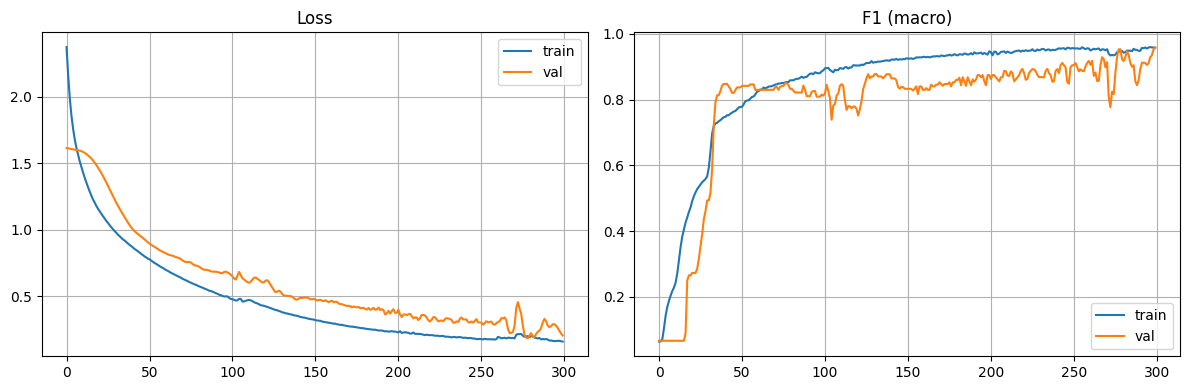

Training complete. Best val F1 = 0.9587 at epoch 300
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9412    0.9697        34
           1     1.0000    1.0000    1.0000        34
           2     0.9429    0.9706    0.9565        34
           3     1.0000    0.9412    0.9697        34
           4     0.9189    1.0000    0.9577        34

    accuracy                         0.9706       170
   macro avg     0.9724    0.9706    0.9707       170
weighted avg     0.9724    0.9706    0.9707       170

Overall Accuracy: 0.9706
Macro Precision: 0.9724
Macro Recall:    0.9706
Macro F1:        0.9707


 Train 51/51,	 User 50
Test user: 50, Val user: 41, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.198, VL=0.410, VF=0.827, best VF=0.941, best Epoch=188]


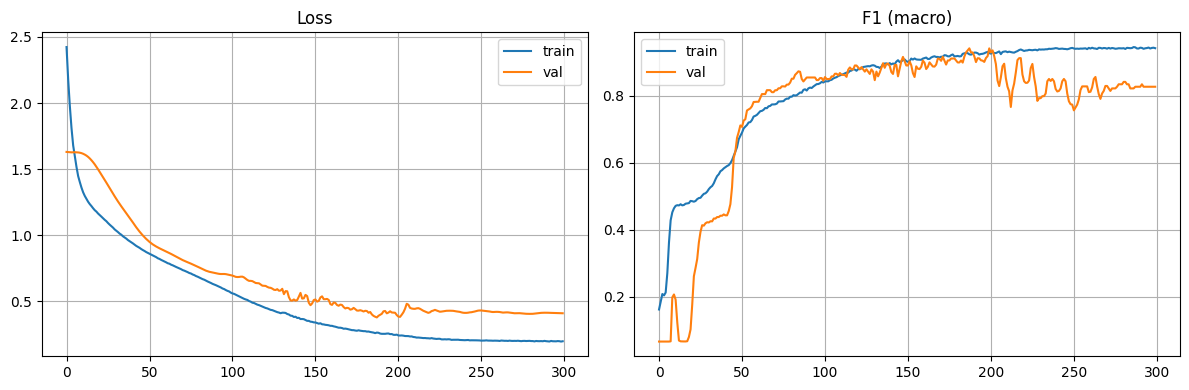

Training complete. Best val F1 = 0.9412 at epoch 188
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9412    0.9412    0.9412        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    0.8824    0.9375        34
           3     1.0000    1.0000    1.0000        34
           4     0.8947    1.0000    0.9444        34

    accuracy                         0.9647       170
   macro avg     0.9672    0.9647    0.9646       170
weighted avg     0.9672    0.9647    0.9646       170

Overall Accuracy: 0.9647
Macro Precision: 0.9672
Macro Recall:    0.9647
Macro F1:        0.9646





 Macro f1 mean = 0.8026,	 std = 0.1728


In [4]:
# Training

import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

test_f1_macro_list = []
np.random.seed(42)

all_users = np.unique(user_windows)
all_activities = np.unique(y_windows)

in_params, hidden, out = 6, 16, 5
    
    # Определяем пользователей с полным набором активностей
full_users = []
for u in all_users:
    mask = (user_windows == u)
    user_acts = np.unique(y_windows[mask])
    if set(user_acts) == set(all_activities):
        full_users.append(u)

for i, user in enumerate(all_users): # enumerate(full_users):
    print(f'\n\n Train {i+1}/{len(all_users)},\t User {user}')
    X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test = split_and_scale_by_user(user, X_windows, y_windows, user_windows, WINDOW_SIZE)

    # Предполагается, что X_train_scaled, X_val_scaled, X_test_scaled,
    # y_train, y_val, y_test уже существуют (из предыдущего шага)
    
    # ------------------ Преобразование в тензоры ------------------
    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val_scaled,   dtype=torch.float32)
    X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
    
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_val_t   = torch.tensor(y_val,   dtype=torch.long)
    y_test_t  = torch.tensor(y_test,  dtype=torch.long)
    
    # ------------------ Создание DataLoader ------------------
    batch_size = 9000
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset   = TensorDataset(X_val_t, y_val_t)
    test_dataset  = TensorDataset(X_test_t, y_test_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)
    
    # ------------------ Расчёт весов классов (по train) ------------------
    classes = np.unique(y_train)
    class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
    
    print(f"Class weights: {weights_tensor}")
    
    # ------------------ Создание модели и вывод параметров ------------------
    #model = SimpleCNN(num_classes=6)
    #model_name='wisdm_simple_cnn'
    
    #model = LNNClassifier(3, 16, 6)
    #model_name='wisdm_lnn'
    
    model = LNNConvClassifier(in_params, hidden, out)
    model_name='siddha_lnn_conv'
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    best_model, history, test_f1_macro = train_model(
        model=model,
        model_name=model_name,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        num_epochs=300,
        lr=1e-3,
        device=device,
        weights=weights_tensor,
        save_dir='models'
    )

    test_f1_macro_list.append(test_f1_macro)

print(f'\n\n\n\n\n Macro f1 mean = {np.mean(test_f1_macro_list):.4f},\t std = {np.std(test_f1_macro_list):.4f}')